# Bài toán 2 — Định giá Bất động sản Việt Nam

**Hệ thống Thông minh · Assignment 01** · Bài toán **hồi quy** (regression) trên
tập 30.229 tin đăng bán nhà đất tại Việt Nam.

Notebook này chạy được từ đầu đến cuối bằng `Kernel → Restart & Run All` và tái
tạo đúng mọi con số xuất hiện trong báo cáo. Toàn bộ logic xử lý dữ liệu, huấn
luyện và đánh giá nằm trong gói `src/`; notebook **gọi lại** các hàm đó chứ
không chép lại, nên notebook, script `run_pipeline.py` và ứng dụng web luôn dùng
chung một biểu diễn dữ liệu duy nhất.

So với bài toán 1, bài toán này khác ở ba điểm đáng chú ý và đó cũng là lý do nó
được chọn làm bài toán song song: **quy mô lớn hơn 40 lần**, **dữ liệu vừa định
lượng vừa định danh** (đòi hỏi mã hoá one-hot), và **mục tiêu liên tục** thay vì
nhị phân (đòi hỏi bộ độ đo hoàn toàn khác).

## Mục lục

| # | Mục | # | Mục |
|---|-----|---|-----|
| 1 | Định nghĩa hệ thống và bài toán | 12 | Mô hình 3 — Random Forest |
| 2 | Sơ đồ hệ thống thông minh | 13 | Mô hình 4 và 5 — SVR, XGBoost |
| 3 | Nguồn dữ liệu | 14 | Đánh giá |
| 4 | Mô tả dữ liệu | 15 | Thực nghiệm 1 — So sánh mô hình |
| 5 | Biểu diễn dữ liệu | 16 | Thực nghiệm 2 — Siêu tham số |
| 6 | Phân tích đặc trưng và mục tiêu | 17 | Thực nghiệm 3 — Biểu diễn dữ liệu |
| 7 | Phân tích khám phá | 18 | Mô hình cuối cùng |
| 8 | Chia train/test | 19 | Ứng dụng |
| 9 | Mô hình cơ sở | 20 | Minh hoạ hệ thống |
| 10 | Mô hình 1 — Linear Regression | 21 | Phản chiếu |
| 11 | Mô hình 2 — Decision Tree | 22 | Kết luận |

### Chuẩn bị môi trường

In [1]:
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
while not (ROOT / "src" / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import config as cfg
from src import evaluate as ev
from src import preprocess as prep
from src import train as tr
from src import viz

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)


def show(name: str, width: int = 720) -> None:
    """Hiển thị biểu đồ mà src/viz.py vừa ghi xuống thư mục figures/."""
    display(Image(filename=str(cfg.FIGURES_DIR / f"{name}.png"), width=width))


print(f"Thư mục gốc dự án    : {ROOT}")
print(f"Hạt giống ngẫu nhiên : RANDOM_STATE = {cfg.RANDOM_STATE}")
print(f"Tỷ lệ tập kiểm tra   : {cfg.TEST_SIZE:.0%} · tập ngoại kiểm {cfg.OOD_SIZE:.0%}")

Thư mục gốc dự án    : D:\Python\HTTM
Hạt giống ngẫu nhiên : RANDOM_STATE = 42
Tỷ lệ tập kiểm tra   : 20% · tập ngoại kiểm 10%


---

## 1. Định nghĩa hệ thống và bài toán

**Hệ thống thông minh** ở đây là một tác tử định giá bất động sản, hỗ trợ người
mua, người bán và nhà đầu tư ước lượng giá hợp lý cho một căn nhà. Mô tả PEAS:

| Thành phần | Nội dung |
|---|---|
| **P** — Độ đo hiệu năng | MAE (sai số tuyệt đối trung bình, đơn vị tỷ VNĐ) và R². MAE đọc được trực tiếp bằng tiền, R² cho biết mô hình giải thích được bao nhiêu phần phương sai của giá. |
| **E** — Môi trường | Thị trường bất động sản Việt Nam, quan sát qua tin đăng bán trên các sàn giao dịch trực tuyến. |
| **A** — Cơ cấu chấp hành | Giá ước lượng kèm khoảng tin cậy và so sánh với mặt bằng giá cùng khu vực. |
| **S** — Bộ cảm biến | Thuộc tính căn nhà do người đăng khai báo: diện tích, số tầng, số phòng, mặt tiền, hướng nhà, tình trạng pháp lý, địa chỉ. |

**Phát biểu bài toán.** Cho tập dữ liệu $D = \{(x_i, y_i)\}_{i=1}^{n}$ với
$x_i$ là mô tả căn nhà thứ $i$ và $y_i \in \mathbb{R}^{+}$ là giá bán (tỷ VNĐ).
Cần học một ánh xạ

$$ f_\theta : \mathcal{X} \rightarrow \mathbb{R}^{+} $$

tối thiểu hoá sai số dự đoán trên các căn nhà chưa từng thấy.

Điểm khác biệt căn bản so với bài toán 1: **không gian đầu vào $\mathcal{X}$
không phải $\mathbb{R}^d$**. Nó pha trộn biến định lượng (diện tích, số tầng) với
biến định danh (tỉnh/thành, hướng nhà, tình trạng pháp lý). Việc đưa $\mathcal{X}$
về không gian số là công việc chính của tầng biểu diễn ở Mục 5, và Mục 17 sẽ đo
xem tầng đó đóng góp bao nhiêu vào kết quả cuối cùng.

---

## 2. Sơ đồ hệ thống thông minh

Cùng kiến trúc sáu tầng với bài toán 1 — điều này có chủ đích: nó cho thấy khung
hệ thống thông minh là **tổng quát**, hai bài toán rất khác nhau vẫn khớp vào
cùng một luồng thông tin. Cái thay đổi nằm ở nội dung từng tầng, không ở cấu
trúc.

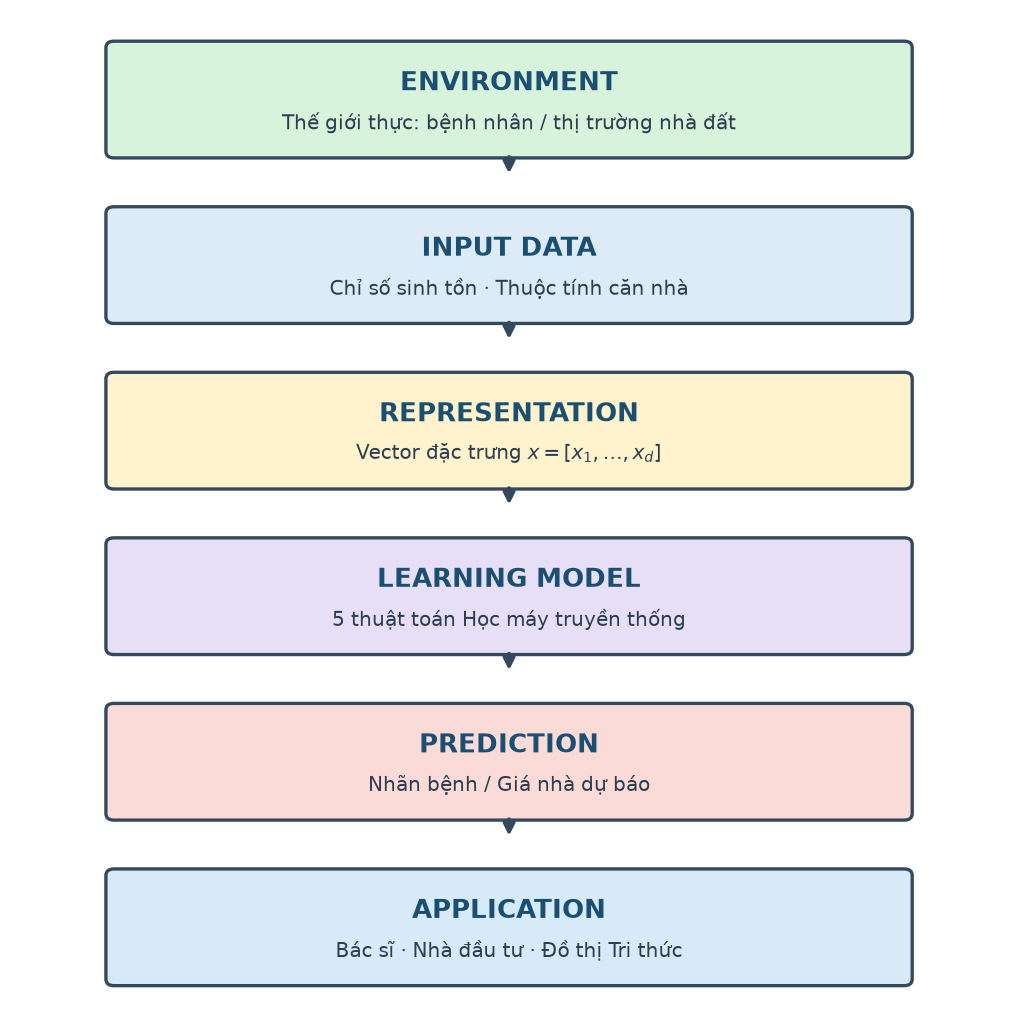

In [2]:
viz.plot_system_diagram()
show("fig_system_diagram", width=560)

---

## 3. Nguồn dữ liệu

**Vietnam Housing Dataset** — dữ liệu thu thập từ tin đăng bán bất động sản trên
các sàn giao dịch trực tuyến Việt Nam, phân phối công khai qua Kaggle.

- **Quy mô:** 30.229 tin đăng, trải khắp các tỉnh thành.
- **Mục tiêu `Price`:** giá rao bán, đơn vị **tỷ VNĐ**.
- **Tệp trong dự án:** `data/raw/vietnam_housing_dataset.csv`.

> **Bẫy kỹ thuật.** Tệp gốc có ký tự **BOM** ở đầu. Đọc bằng `utf-8` thường sẽ
> khiến tên cột đầu tiên dính một ký tự vô hình và mọi phép chọn cột đều lỗi với
> thông báo khó hiểu. Hàm `prep.load_housing_raw()` dùng `encoding="utf-8-sig"`
> để xử lý việc này một lần, đúng chỗ.

**Lưu ý về tính chất dữ liệu.** Đây là giá **rao bán**, không phải giá giao dịch
thành công, và do người đăng tự khai báo. Hệ quả là dữ liệu chứa nhiễu thật:
tiêu đề quảng cáo lọt vào trường địa chỉ, giá rao cao hơn giá thật, thông tin
khuyết. Mục 21 phân tích ảnh hưởng của điều này tới trần hiệu năng đạt được.

Ngoài ra, biến mục tiêu đã được **cắt biên từ trước khi phát hành**: giá chỉ nằm
trong khoảng 1 – 11,5 tỷ VNĐ, không có tin nào ngoài dải này. Mục 6 định lượng
hệ quả của việc cắt biên, và Mục 21.5 ghi nhận nó như một ràng buộc về phạm vi
áp dụng của hệ thống.

In [3]:
raw = prep.load_housing_raw()

print(f"Tệp nguồn : {cfg.HOUSING_CSV.relative_to(ROOT)}")
print(f"Kích thước: {raw.shape[0]:,} tin đăng × {raw.shape[1] - 1} thuộc tính + 1 mục tiêu")
print(f"Tên cột   : {list(raw.columns)}")
raw.head()

Tệp nguồn : data\raw\vietnam_housing_dataset.csv
Kích thước: 30,229 tin đăng × 11 thuộc tính + 1 mục tiêu
Tên cột   : ['Address', 'Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state', 'Price']


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


---

## 4. Mô tả dữ liệu

| Cột | Ý nghĩa | Kiểu |
|---|---|---|
| `Address` | Địa chỉ dạng văn bản tự do | Văn bản |
| `Area` | Diện tích đất | Định lượng (m²) |
| `Frontage` | Chiều rộng mặt tiền | Định lượng (m) |
| `Access Road` | Chiều rộng đường vào | Định lượng (m) |
| `House direction` | Hướng nhà | Định danh |
| `Balcony direction` | Hướng ban công | Định danh |
| `Floors` | Số tầng | Định lượng |
| `Bedrooms` | Số phòng ngủ | Định lượng |
| `Bathrooms` | Số phòng vệ sinh | Định lượng |
| `Legal status` | Tình trạng pháp lý | Định danh |
| `Furniture state` | Tình trạng nội thất | Định danh |
| **`Price`** | **Giá rao bán (tỷ VNĐ)** | **Mục tiêu** |

In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 5.4 MB


In [5]:
raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Area,30229.0,68.50,48.07,3.1,40.0,56.0,80.0,595.0
Frontage,18665.0,5.36,4.35,1.0,4.0,4.5,5.0,77.0
Access Road,16932.0,7.85,7.45,1.0,4.0,6.0,10.0,85.0
Floors,26626.0,3.41,1.33,1.0,2.0,3.0,4.0,10.0
Bedrooms,25067.0,3.51,1.31,1.0,3.0,3.0,4.0,9.0
Bathrooms,23155.0,3.35,1.40,1.0,2.0,3.0,4.0,9.0
Price,30229.0,5.87,2.21,1.0,4.2,5.9,7.5,11.5


Vấn đề nổi bật của tập này **không** phải giá trị mã hoá sai như bài toán 1, mà
là **dữ liệu khuyết trên diện rộng**. Bảng dưới đây xếp hạng tỷ lệ khuyết theo
từng cột.

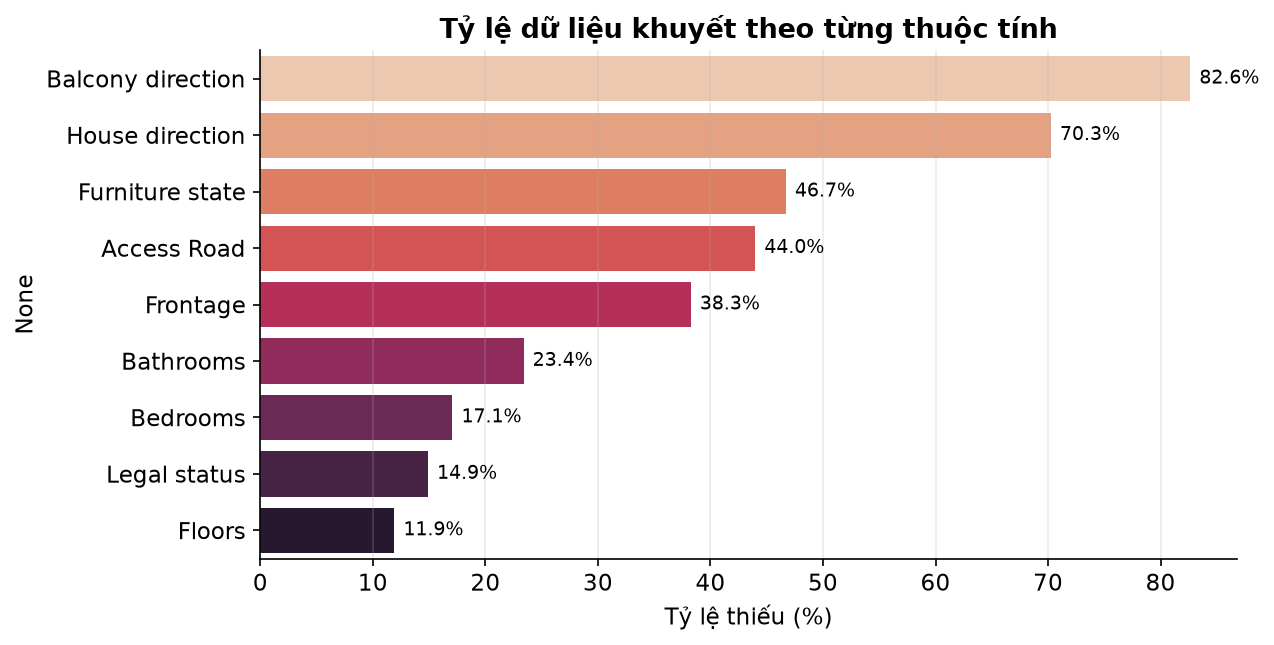

,Tỷ lệ khuyết (%)
Balcony direction,82.65
House direction,70.26
Furniture state,46.71
Access Road,43.99
Frontage,38.25
Bathrooms,23.40
Bedrooms,17.08
Legal status,14.91
Floors,11.92
Area,0.00


In [6]:
missing = (raw.isna().mean() * 100).sort_values(ascending=False).round(2)
viz.plot_missing_bar(raw, "hou_missing_ratio")
show("hou_missing_ratio", width=720)

missing.rename("Tỷ lệ khuyết (%)").to_frame()

---

## 5. Biểu diễn dữ liệu

Tầng biểu diễn ở đây nặng hơn bài toán 1 rất nhiều, vì đầu vào không sẵn ở dạng
số. Bốn thao tác lần lượt được áp dụng.

### (a) Loại cột thiếu quá nhiều

Cột nào khuyết trên **80%** sẽ bị loại. Lý do: điền khuyết ở mức đó chỉ tạo ra
một hằng số giả cho gần như toàn bộ cột — nó không mang thông tin nào mà còn
thêm một chiều nhiễu cho mô hình.

### (b) Tách địa chỉ văn bản thành hai cấp hành chính

`Address` là văn bản tự do, không dùng trực tiếp được. Địa chỉ Việt Nam tuân
theo quy ước đọc từ nhỏ đến lớn — `… , Phường/Xã , Quận/Huyện , Tỉnh/Thành` —
nên phần tử cuối là cấp tỉnh và phần tử áp chót là cấp huyện, bất kể chuỗi dài
bao nhiêu đoạn.

Chuỗi dưới 3 đoạn **không** phải địa chỉ hành chính mà là tiêu đề tin rao (ví dụ
*"Bán nhà chính chủ Phó Đức Chính"*), nên được gán `"Không rõ"` thay vì tách bừa.
Đây là ví dụ điển hình của việc **biểu diễn phải chịu trách nhiệm cho dữ liệu
bẩn**, không đẩy vấn đề xuống cho mô hình.

### (c) Điền khuyết theo bản chất biến

| Loại biến | Cách điền | Lý do |
|---|---|---|
| Định lượng | Trung vị | Bền với giá trị ngoại lai hơn trung bình, quan trọng khi phân bố lệch mạnh như giá nhà. |
| Định danh | Hạng mục riêng `"Không rõ"` | Việc **không khai báo** tự nó là thông tin: tin đăng giấu tình trạng pháp lý thường khác về giá so với tin ghi rõ "sổ đỏ". Gán bừa hạng mục phổ biến nhất sẽ xoá mất tín hiệu đó. |

### (d) Thiết kế đặc trưng phái sinh

| Đặc trưng | Công thức | Nghiệp vụ được mã hoá |
|---|---|---|
| `Total_Area` | `Area × max(Floors, 1)` | Môi giới định giá theo **tổng diện tích sử dụng**, không theo diện tích đất. |
| `Room_Density` | `(Bedrooms + Bathrooms) / Area` | Mật độ khai thác căn nhà — phân biệt nhà ở với nhà cho thuê phòng. |
| `Frontage_Ratio` | `Frontage / Area` | Phân biệt nhà phố mặt đường với nhà trong hẻm — chênh lệch giá giữa hai loại này rất lớn. |

### (e) Mã hoá one-hot cho biến định danh

Mỗi giá trị định danh thành một cột nhị phân, **giới hạn 30 hạng mục phổ biến
nhất** mỗi biến. Không giới hạn thì `District` với hàng trăm giá trị sẽ tạo ma
trận thưa khổng lồ và mô hình sẽ học thuộc từng quận hiếm thay vì học quy luật
giá.

In [7]:
cleaned, dropped = prep.clean_housing(raw)

print(f"Cột bị loại vì thiếu trên {cfg.MISSING_DROP_THRESHOLD:.0%}: {dropped}")
print(f"Sau làm sạch: {cleaned.shape[0]:,} dòng × {cleaned.shape[1]} cột")
print(f"Còn giá trị khuyết: {int(cleaned.isna().sum().sum())}")

cleaned[["Province", "District", "Area", "Floors", "Legal status", "Price"]].head()

Cột bị loại vì thiếu trên 80%: ['Balcony direction']
Sau làm sạch: 30,229 dòng × 12 cột
Còn giá trị khuyết: 0


,Province,District,Area,Floors,Legal status,Price
0,Hưng Yên,Văn Giang,84.0,4.0,Have certificate,8.60
1,Hưng Yên,Văn Giang,60.0,5.0,Không rõ,7.50
2,Hưng Yên,Văn Giang,90.0,5.0,Sale contract,8.90
3,Hồ Chí Minh,Gò Vấp,54.0,2.0,Have certificate,5.35
4,Hồ Chí Minh,Gò Vấp,92.0,2.0,Have certificate,6.90


Kiểm chứng bước tách địa chỉ — bao nhiêu tin đăng có địa chỉ hành chính đọc được,
bao nhiêu tin thực chất chỉ là tiêu đề quảng cáo:

In [8]:
n_unknown = int((cleaned["Province"] == "Không rõ").sum())
print(f"Tách được cấp tỉnh/thành : {len(cleaned) - n_unknown:,} tin "
      f"({1 - n_unknown / len(cleaned):.2%})")
print(f"Không tách được          : {n_unknown:,} tin "
      f"({n_unknown / len(cleaned):.2%}) — tiêu đề quảng cáo, không phải địa chỉ")
print(f"\nSố tỉnh/thành phân biệt : {cleaned['Province'].nunique()}")
print(f"Số quận/huyện phân biệt : {cleaned['District'].nunique()}")

cleaned["Province"].value_counts().head(10).rename("Số tin đăng").to_frame()

Tách được cấp tỉnh/thành : 30,223 tin (99.98%)
Không tách được          : 6 tin (0.02%) — tiêu đề quảng cáo, không phải địa chỉ

Số tỉnh/thành phân biệt : 75
Số quận/huyện phân biệt : 342


,Số tin đăng
Province,
Hồ Chí Minh,11778
Hà Nội,10457
Bình Dương,1671
Đà Nẵng,1437
Đồng Nai,829
Hải Phòng,789
Khánh Hòa,743
Hưng Yên,404
Long An,339


In [9]:
engineered = prep.add_housing_features(cleaned)
new_cols = ["Total_Area", "Room_Density", "Frontage_Ratio"]

print(f"Biểu diễn: {cleaned.shape[1] - 1} cột → {engineered.shape[1] - 1} cột "
      f"(thêm {len(new_cols)} đặc trưng thiết kế)")
engineered[["Area", "Floors", "Bedrooms", "Bathrooms", "Frontage"] + new_cols].head()

Biểu diễn: 11 cột → 14 cột (thêm 3 đặc trưng thiết kế)


,Area,Floors,Bedrooms,Bathrooms,Frontage,Total_Area,Room_Density,Frontage_Ratio
0,84.0,4.0,3.0,3.0,4.5,336.0,0.071429,0.053571
1,60.0,5.0,3.0,3.0,4.5,300.0,0.100000,0.075000
2,90.0,5.0,3.0,3.0,6.0,450.0,0.066667,0.066667
3,54.0,2.0,2.0,3.0,4.5,108.0,0.092593,0.083333
4,92.0,2.0,4.0,4.0,4.5,184.0,0.086957,0.048913


---

## 6. Phân tích đặc trưng và mục tiêu

**Phân bố của biến mục tiêu** quyết định cách đọc mọi độ đo về sau.

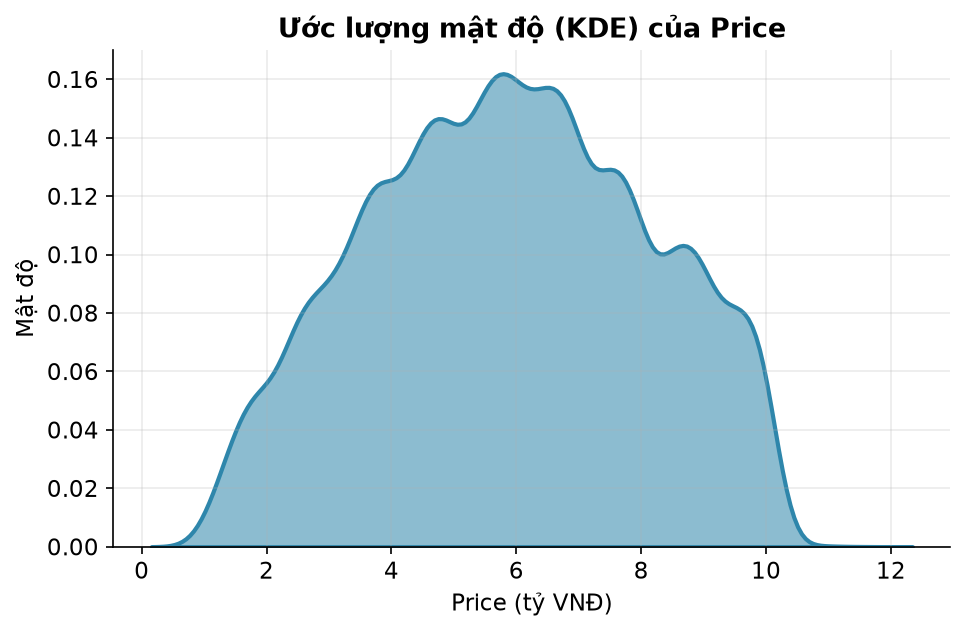

Trung bình : 5.872 tỷ VNĐ
Trung vị   : 5.900 tỷ VNĐ
Độ lệch chuẩn: 2.212
Nhỏ nhất / lớn nhất: 1.000 / 11.500 tỷ VNĐ
Hệ số bất đối xứng (skewness): -0.029
Độ nhọn (kurtosis)           : -0.846
Bách phân vị 1% / 99%        : 1.45 / 10.00


In [10]:
viz.plot_kde(cleaned, cfg.HOUSING_TARGET, "hou_kde_price", "(tỷ VNĐ)")
show("hou_kde_price", width=600)

price = cleaned[cfg.HOUSING_TARGET]
print(f"Trung bình : {price.mean():.3f} tỷ VNĐ")
print(f"Trung vị   : {price.median():.3f} tỷ VNĐ")
print(f"Độ lệch chuẩn: {price.std():.3f}")
print(f"Nhỏ nhất / lớn nhất: {price.min():.3f} / {price.max():.3f} tỷ VNĐ")
print(f"Hệ số bất đối xứng (skewness): {price.skew():.3f}")
print(f"Độ nhọn (kurtosis)           : {price.kurtosis():.3f}")
print(f"Bách phân vị 1% / 99%        : {price.quantile(0.01):.2f} / {price.quantile(0.99):.2f}")

Kết quả **đi ngược kỳ vọng ban đầu** và cần được ghi nhận đúng như nó là.

Giá bất động sản trong thực tế lệch phải rất mạnh: phần lớn giao dịch ở phân
khúc phổ thông, một đuôi dài các bất động sản cao cấp kéo trung bình lên. Nhưng
ở tập dữ liệu này, trung bình **xấp xỉ bằng** trung vị, hệ số bất đối xứng gần
**0**, và độ nhọn **âm** — phân bố gần đối xứng, thậm chí bẹt hơn phân bố chuẩn.
Toàn bộ giá nằm gọn trong khoảng 1 – 11,5 tỷ VNĐ.

Cách đọc đúng: **tập dữ liệu đã bị cắt biên từ trước khi phát hành**, cả đuôi rẻ
lẫn đuôi đắt đều bị loại. Cái quan sát được không phải phân bố giá của thị
trường, mà là phân bố giá của **phần thị trường mà người phát hành dữ liệu giữ
lại**.

Ba hệ quả trực tiếp lên phần còn lại của notebook:

1. **Mô hình cơ sở đoán trung vị hay trung bình gần như không khác nhau** ở tập
   này (Mục 9). Trung vị vẫn được giữ vì đó là lựa chọn đúng về nguyên tắc cho
   biến giá, nhưng không nên viện dẫn "phân bố lệch" làm lý do — dữ liệu không
   ủng hộ lập luận đó.
2. **Phương sai của mục tiêu bị thu hẹp**, nên $R^2$ ở đây khắt khe hơn so với
   $R^2$ tính trên dải giá đầy đủ: mẫu số của $R^2$ nhỏ đi trong khi phần khó dự
   đoán vẫn còn nguyên.
3. **Phạm vi áp dụng của hệ thống bị giới hạn** trong đúng dải 1 – 11,5 tỷ VNĐ.
   Đưa vào một biệt thự 80 tỷ là ngoại suy ngoài miền huấn luyện, và mô hình dựa
   trên cây **không** ngoại suy được — nó chỉ trả về giá trị lá gần nhất.

In [11]:
corr_target = (
    engineered.select_dtypes(include="number")
              .drop(columns=[cfg.HOUSING_TARGET])
              .corrwith(engineered[cfg.HOUSING_TARGET])
              .sort_values(key=abs, ascending=False)
              .rename("Tương quan với Price")
              .to_frame()
              .round(4)
)
corr_target

,Tương quan với Price
Bathrooms,0.3640
Bedrooms,0.3325
Floors,0.3091
Total_Area,0.2949
Access Road,0.1130
Area,0.0976
Frontage_Ratio,-0.0715
Room_Density,0.0397
Frontage,0.0387


Tương quan tuyến tính của **mọi** đặc trưng định lượng với giá đều ở mức khiêm
tốn. Đây là tín hiệu quan trọng, không phải tin xấu: nó dự báo rằng mô hình
tuyến tính sẽ yếu (Mục 15 xác nhận R² ≈ 0.36 cho Linear Regression) và phần lớn
sức mạnh dự báo phải đến từ **quan hệ phi tuyến** cùng **biến định danh** — mà
tương quan Pearson vốn không nhìn thấy. Mục 17 kiểm chứng trực tiếp giả thuyết
này bằng thực nghiệm.

---

## 7. Phân tích khám phá (EDA)

### 7.1 Phân bố đơn biến

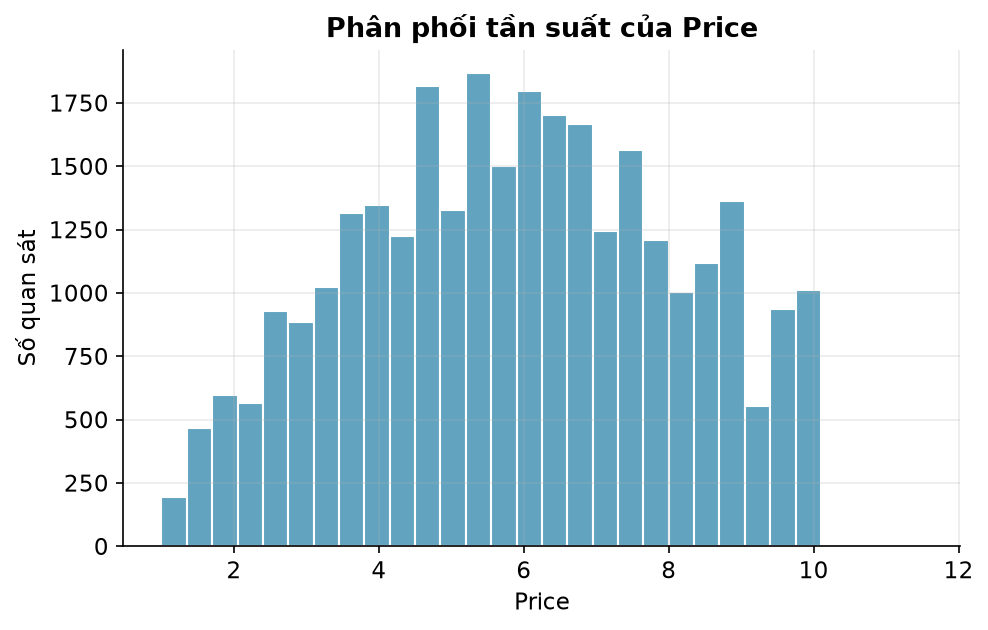

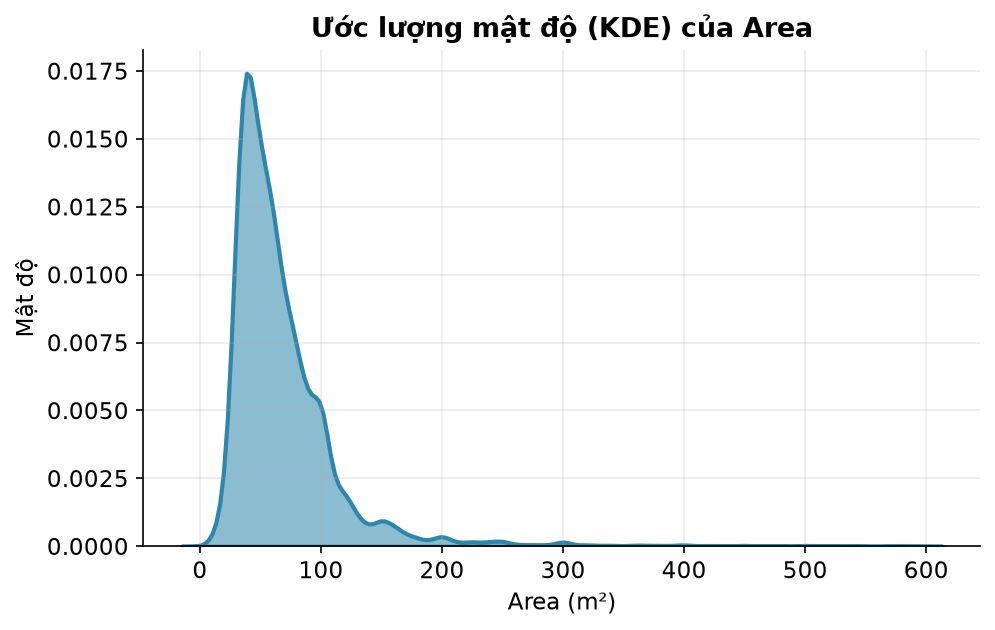

In [12]:
viz.plot_histogram(cleaned, cfg.HOUSING_TARGET, "hou_hist_price")
show("hou_hist_price", width=600)

viz.plot_kde(cleaned, "Area", "hou_kde_area", "(m²)")
show("hou_kde_area", width=600)

### 7.1b Ba biến người mua thật sự cân nhắc

Giá, Diện tích và Số phòng ngủ là ba trục mà mọi người mua nhà đều so đo.
Vẽ riêng lẻ từng phân phối chỉ trả lời được câu hỏi **biên**; hình sáu bảng
dưới đây trả lời câu hỏi **quan hệ**, và trong tập dữ liệu này chính quan hệ
mới là chỗ có phát hiện bất ngờ.

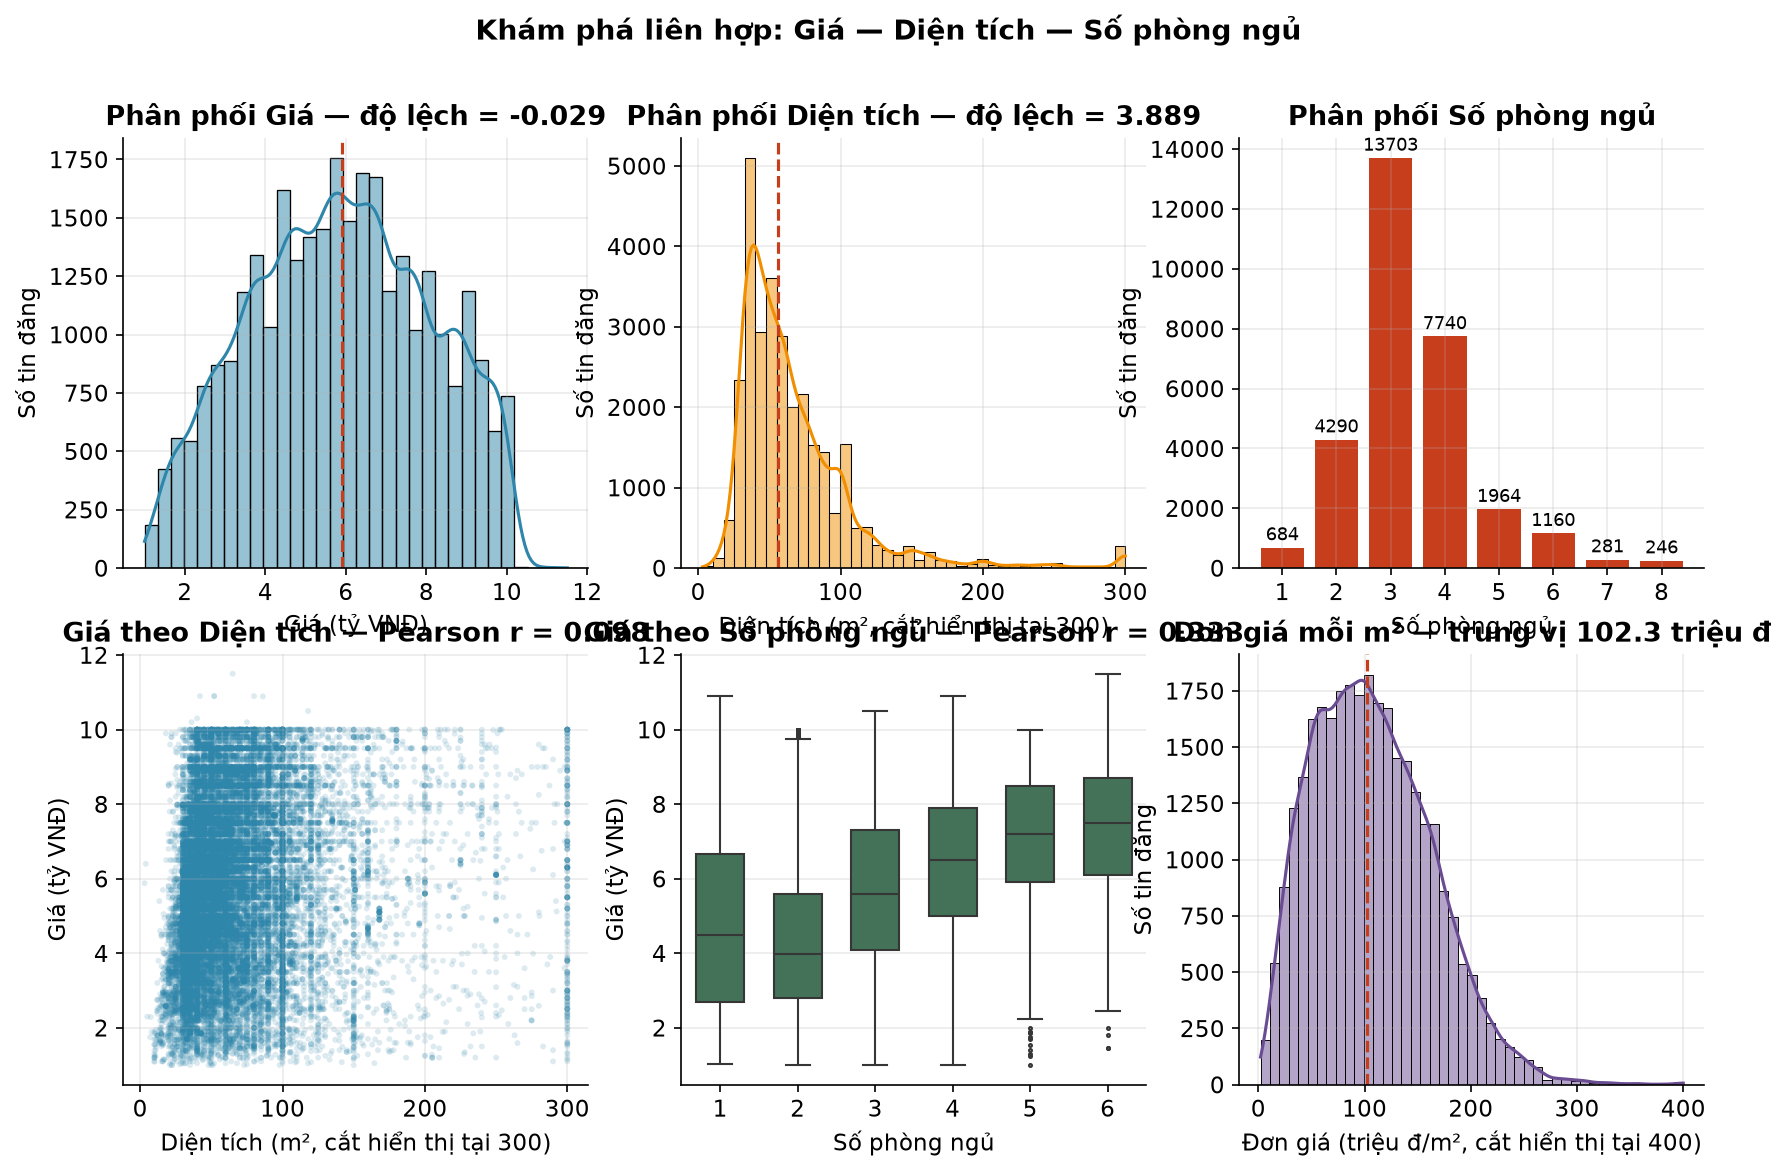

In [13]:
viz.plot_price_area_bedrooms(
    cleaned, "hou_price_area_bedrooms",
    "Khám phá liên hợp: Giá — Diện tích — Số phòng ngủ")
show("hou_price_area_bedrooms", width=920)

Ba điều đọc được từ hình này, cả ba đều đi ngược trực giác thông thường:

1. **Giá gần như đối xứng** (độ lệch ≈ −0,03) trong khi **Diện tích lệch
   phải rất mạnh**. Hai biến ở hai chế độ phân phối khác hẳn nhau, nên phép
   biến đổi log — thường được mặc định áp cho giá nhà — sẽ làm hỏng biến
   mục tiêu ở đây chứ không cải thiện nó.
2. **Diện tích gần như không định giá được căn nhà** ($r$ chỉ khoảng 0,10).
   Hộp phân bố giá theo số phòng ngủ cũng chồng lấn gần hết. Không đặc trưng
   vật lý nào một mình mang đủ tín hiệu.
3. **Đơn giá mỗi mét vuông thì lệch phải rất mạnh** — đây mới là biến giữ
   đúng hình dáng mà trực giác về thị trường bất động sản mong đợi, và nó
   là biến bị *ẩn* đi khi ta chỉ nhìn Giá và Diện tích tách rời.

### 7.2 Giá trị ngoại lai

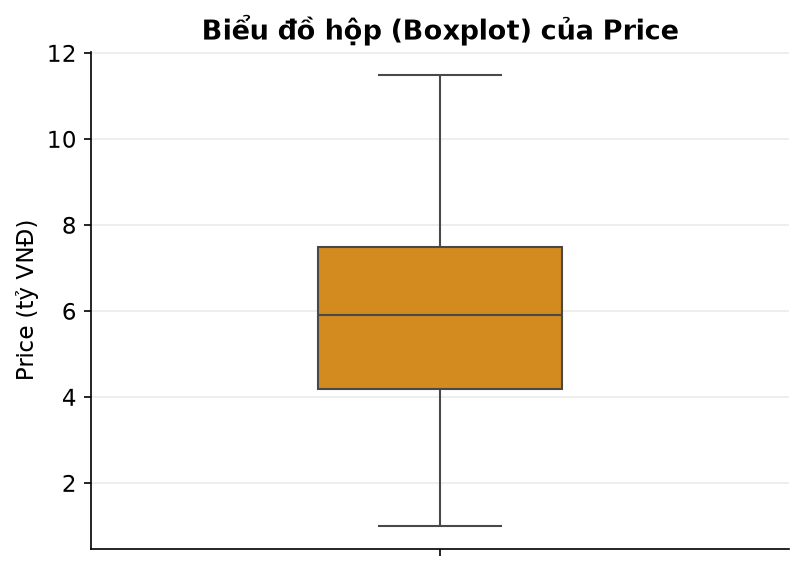

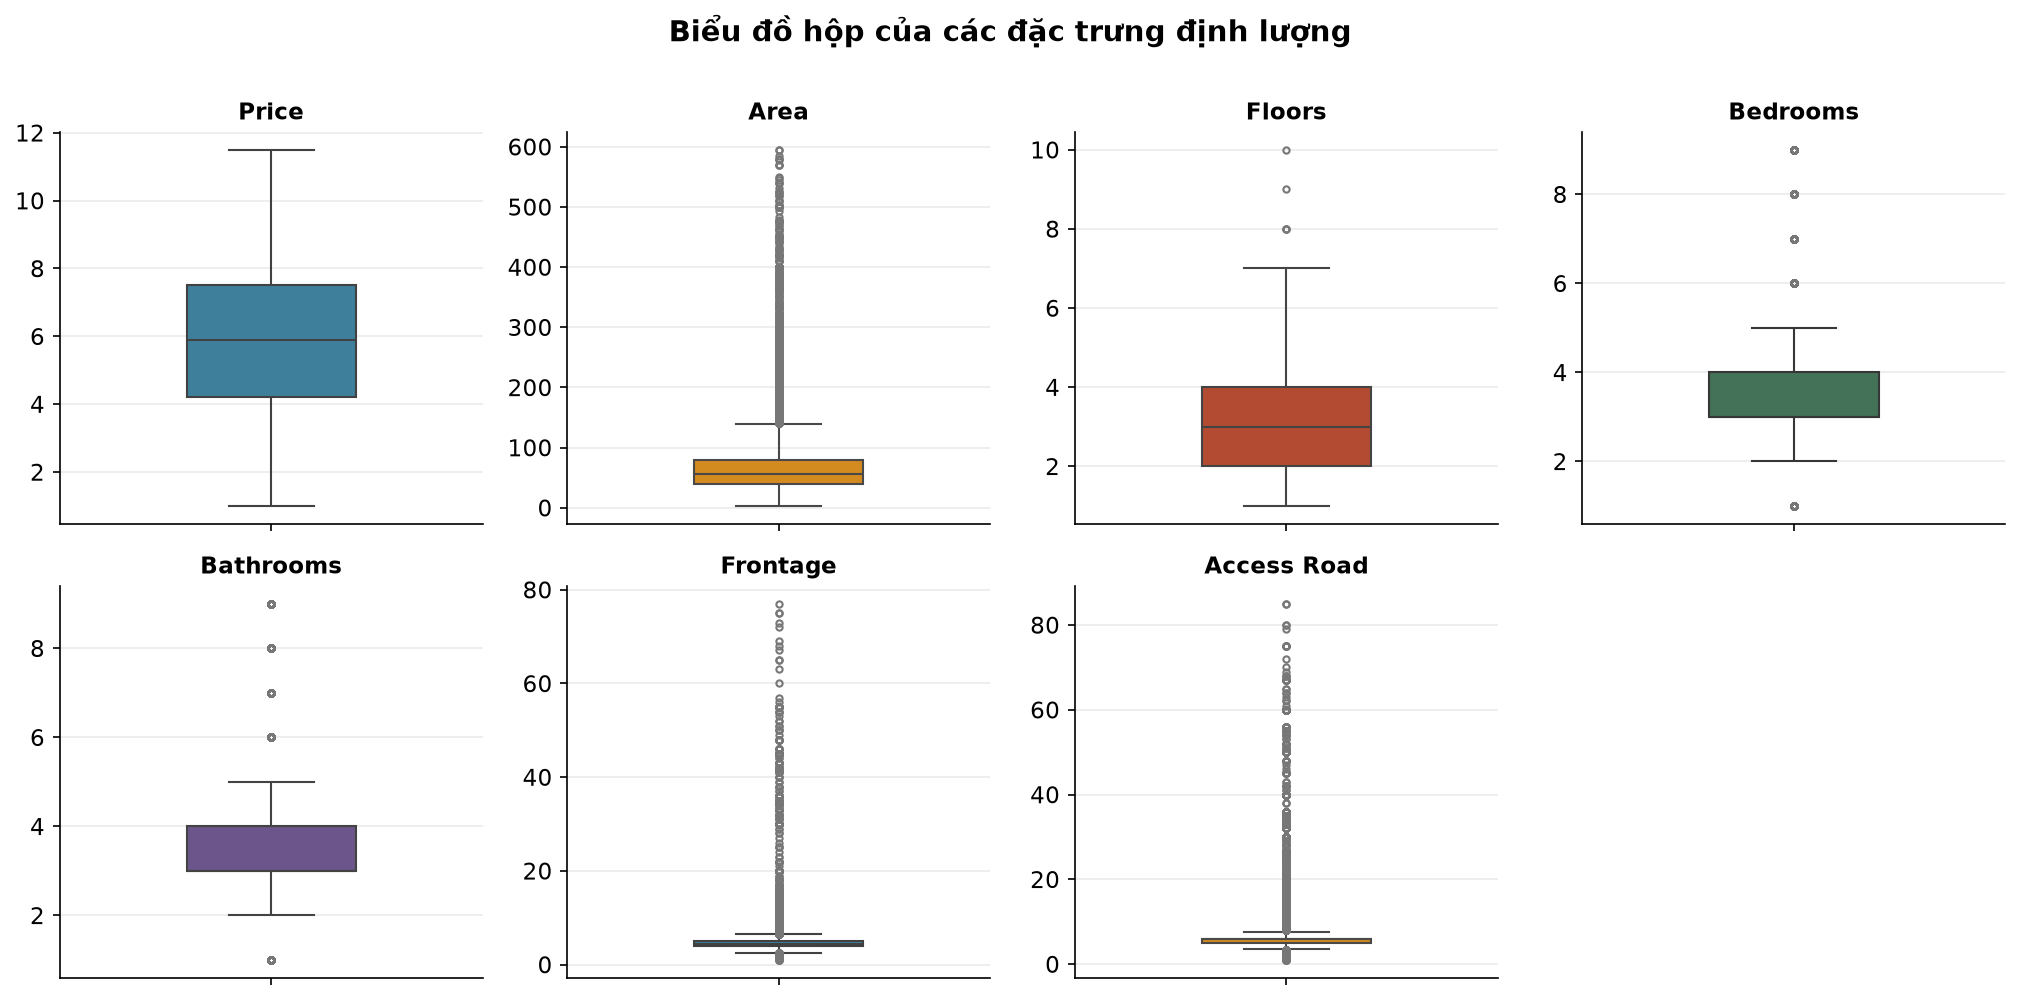

In [14]:
viz.plot_boxplot(cleaned, cfg.HOUSING_TARGET, "hou_box_price", "(tỷ VNĐ)")
show("hou_box_price", width=600)

viz.plot_boxplot_grid(
    cleaned,
    ["Price", "Area", "Floors", "Bedrooms", "Bathrooms", "Frontage", "Access Road"],
    "hou_box_grid", ncols=4,
)
show("hou_box_grid", width=860)

Hai bức tranh trái ngược nhau, và sự trái ngược đó chính là thông tin.

**Biến mục tiêu `Price` gần như không có ngoại lai** — hệ quả trực tiếp của việc
tập dữ liệu đã bị cắt biên (Mục 6). **Các đặc trưng đầu vào thì ngược lại**:
`Area` trải từ 3 m² tới 595 m², `Frontage` và `Access Road` cũng có đuôi dài rõ
rệt.

Điều này tạo ra một tình huống đáng chú ý về mặt học máy: **không gian đầu vào
rộng hơn nhiều so với không gian đầu ra**. Những căn có diện tích cực lớn vẫn bị
buộc phải rơi vào dải giá ≤ 11,5 tỷ, nên quan hệ diện tích – giá bị nén lại ở
vùng đầu trên. Mục 15 sẽ đo được hệ quả của điều này dưới dạng độ chệch có hệ
thống theo phân khúc giá.

Ngoại lai ở đầu vào **không** bị loại bỏ: nhà 3 m² và nhà 595 m² đều là tin đăng
có thật, và mô hình dựa trên cây vốn bền với ngoại lai theo thiết kế.

### 7.3 Quan hệ giữa diện tích và giá

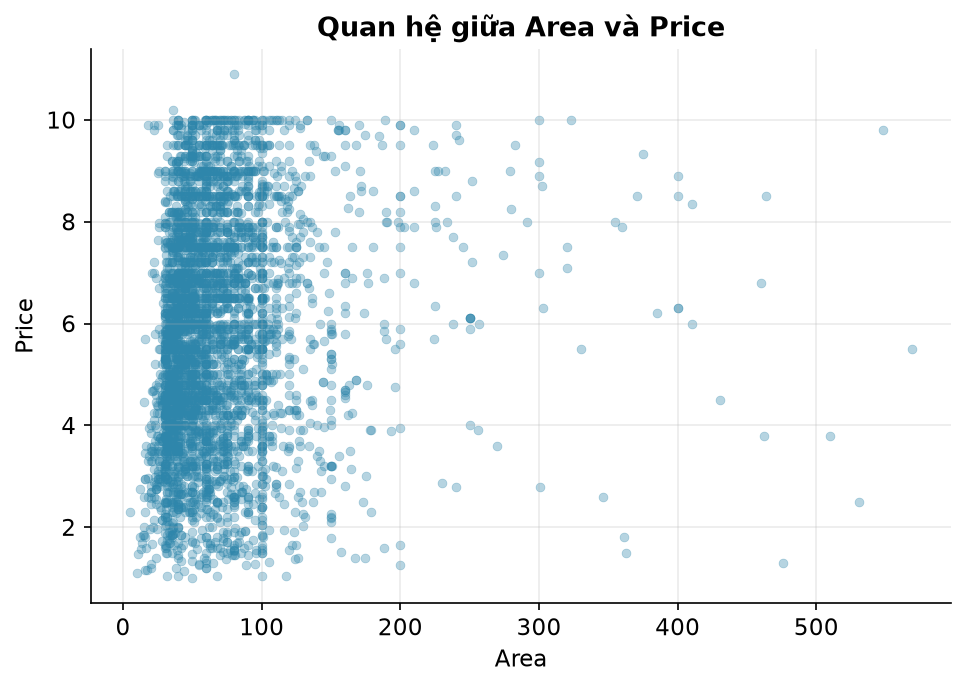

In [15]:
viz.plot_scatter(cleaned, "Area", cfg.HOUSING_TARGET, "hou_scatter_area_price")
show("hou_scatter_area_price", width=680)

Quan hệ tồn tại nhưng **phân tán rất rộng**: cùng một mức diện tích có thể ứng
với giá chênh nhau hàng chục lần. Diện tích một mình không đủ định giá — phần
phương sai còn lại phải được giải thích bằng **vị trí**, và đó chính là điều mục
7.4 kiểm tra.

### 7.4 Vị trí hành chính — nhóm thông tin quyết định

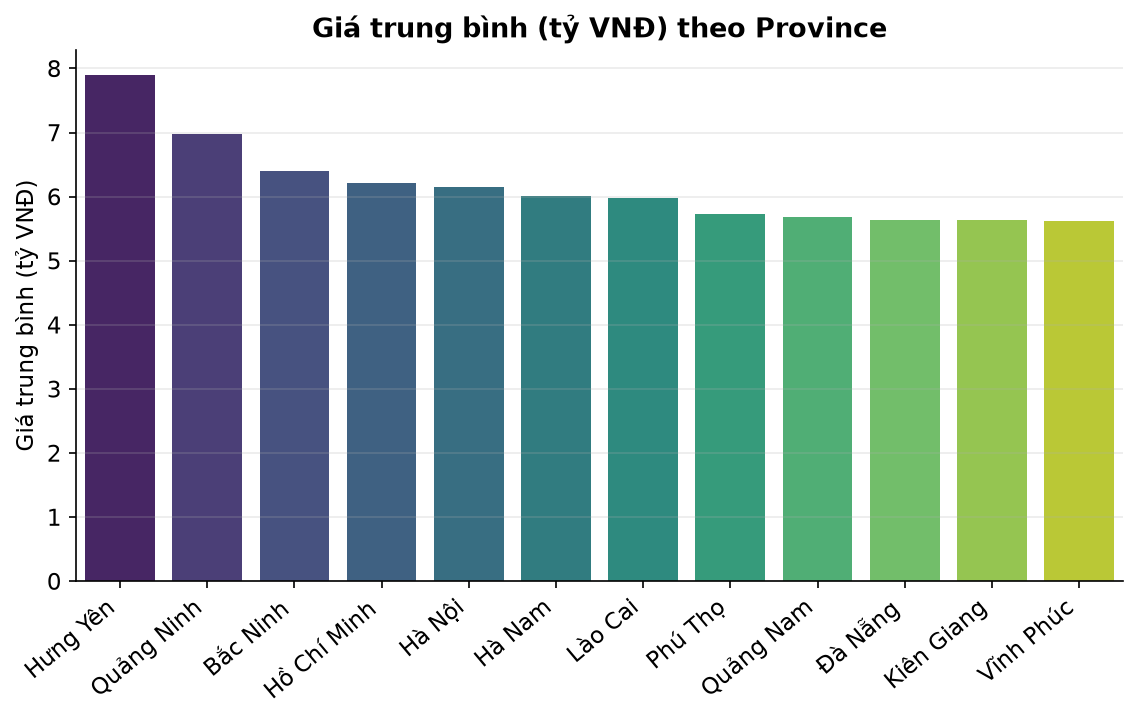

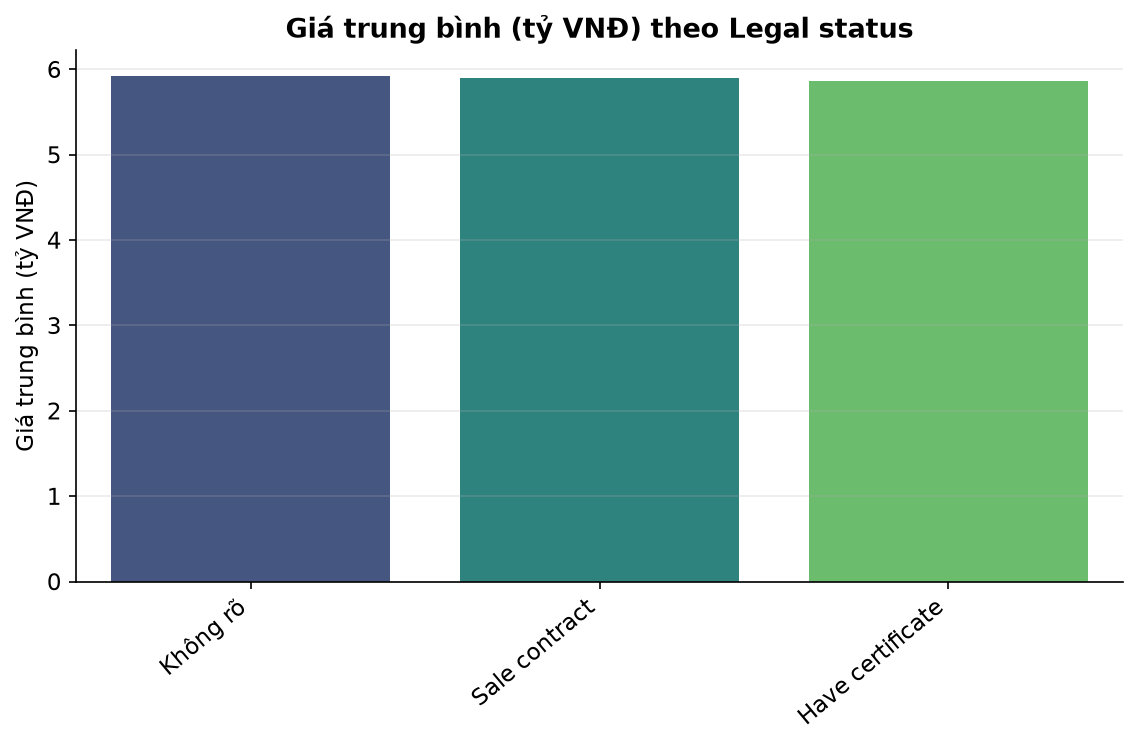

In [16]:
viz.plot_category_bar(cleaned, "Province", cfg.HOUSING_TARGET, "hou_bar_province")
show("hou_bar_province", width=780)

viz.plot_category_bar(cleaned, "Legal status", cfg.HOUSING_TARGET, "hou_bar_legal", top=5)
show("hou_bar_legal", width=680)

Chênh lệch giá trung bình giữa các tỉnh/thành lớn hơn hẳn chênh lệch do bất kỳ
đặc trưng định lượng nào tạo ra. Đây là bằng chứng khám phá cho giả thuyết mà
Thực nghiệm 3 (Mục 17) sẽ kiểm định chính thức: **bỏ biến định danh đi thì mô
hình sụp đổ**.

Tình trạng pháp lý cũng phân tách giá rõ rệt — tin đăng có "sổ đỏ/sổ hồng" khác
hẳn tin không khai báo. Điều này biện minh cho quyết định ở Mục 5(c): giữ
`"Không rõ"` làm một hạng mục riêng thay vì điền bừa.

### 7.5 Tương quan giữa các đặc trưng

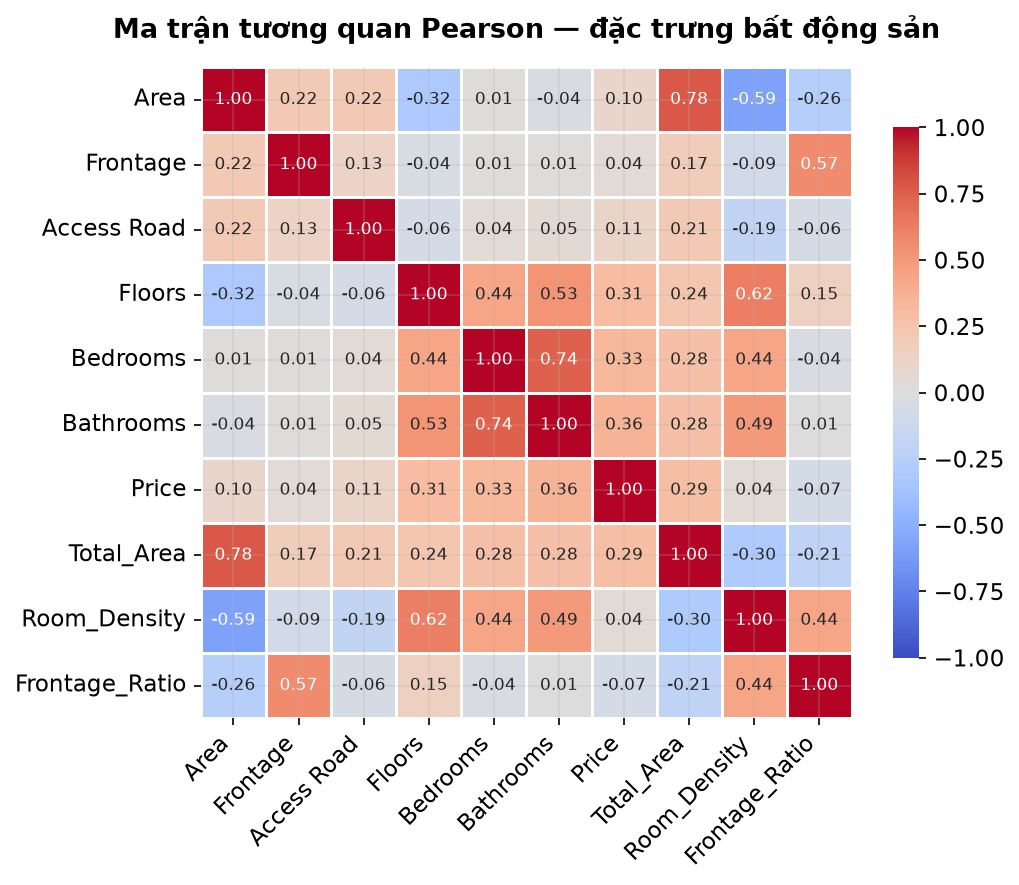

In [17]:
viz.plot_correlation_heatmap(
    engineered, "hou_corr_heatmap",
    "Ma trận tương quan Pearson — đặc trưng bất động sản",
)
show("hou_corr_heatmap", width=760)

Cặp `Area` – `Total_Area` tương quan cao theo đúng định nghĩa (`Total_Area` được
tính từ `Area`). Với mô hình dựa trên cây, đa cộng tuyến không gây hại — cây chỉ
chọn một trong hai để tách nút. Với Linear Regression thì nó làm hệ số kém ổn
định, và đây là một phần lý do mô hình tuyến tính xếp cuối ở Mục 15.

---

## 8. Chia tập huấn luyện / kiểm tra / ngoại kiểm

Cùng giao thức ba tập với bài toán 1: tập ngoại kiểm 10% được cắt ra **trước
tiên** và không tham gia bất kỳ bước phát triển nào.

Khác biệt duy nhất: **không phân tầng** (`stratify`). Phân tầng chỉ định nghĩa
được trên biến rời rạc; ở đây mục tiêu là biến liên tục. Với 30.229 quan sát,
phép chia ngẫu nhiên đủ để ba tập có phân bố giá tương đương — ô dưới đây kiểm
chứng chính điều đó thay vì giả định.

In [18]:
X, y, _ = prep.prepare_housing(engineered=True)
numeric, categorical = prep.housing_column_types(X)

print(f"Biểu diễn đầu vào: {len(numeric)} đặc trưng định lượng, "
      f"{len(categorical)} đặc trưng định danh")
print(f"  Định lượng: {numeric}")
print(f"  Định danh : {categorical}")

X_train, X_test, X_ood, y_train, y_test, y_ood = tr.three_way_split(X, y)

split_table = pd.DataFrame(
    {
        "Số quan sát": [len(X_train), len(X_test), len(X_ood)],
        "Giá trung bình": [y_train.mean(), y_test.mean(), y_ood.mean()],
        "Giá trung vị": [y_train.median(), y_test.median(), y_ood.median()],
    },
    index=["Huấn luyện", "Kiểm tra", "Ngoại kiểm"],
).round(4)
split_table

Biểu diễn đầu vào: 9 đặc trưng định lượng, 5 đặc trưng định danh
  Định lượng: ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms', 'Total_Area', 'Room_Density', 'Frontage_Ratio']
  Định danh : ['House direction', 'Legal status', 'Furniture state', 'Province', 'District']


,Số quan sát,Giá trung bình,Giá trung vị
Huấn luyện,21764,5.8757,5.90
Kiểm tra,5442,5.8361,5.88
Ngoại kiểm,3023,5.9108,5.90


Ba tập có trung bình và trung vị sát nhau — phép chia ngẫu nhiên hoạt động đúng
như mong đợi ở quy mô này.

---

## 9. Mô hình cơ sở (Baseline)

Mô hình cơ sở luôn dự đoán **giá trung vị** của tập huấn luyện, bất kể căn nhà
có thuộc tính gì (`DummyRegressor`). Trung vị là lựa chọn đúng về nguyên tắc cho
biến giá vì nó bền với ngoại lai; ở tập dữ liệu đã cắt biên này, chênh lệch so
với trung bình là không đáng kể (Mục 6) nên lựa chọn đó ít ảnh hưởng tới kết quả.

Đây là mốc mà mọi mô hình học được phải vượt qua (yêu cầu R6). Giá trị $R^2$ của
nó xấp xỉ **0** theo đúng định nghĩa: $R^2$ đo phần phương sai giải thích được
so với chính phép đoán hằng số này.

In [19]:
def make_prep():
    """Tạo bộ tiền xử lý mới cho mỗi mô hình — dùng chung một instance sẽ khiến
    các pipeline chia sẻ trạng thái đã fit."""
    return tr.mixed_preprocessor(numeric, categorical)


baseline = tr.make_pipeline(make_prep(), tr.build_regressor_baseline())
baseline.fit(X_train, y_train)

base_metrics = ev.regression_metrics(y_test, baseline.predict(X_test))
pd.DataFrame([base_metrics], index=["Baseline (đoán trung vị)"]).round(4)

,MAE,MSE,RMSE,R2
Baseline (đoán trung vị),1.8587,4.9573,2.2265,-0.0008


MAE ≈ 1.86 tỷ VNĐ có nghĩa: nếu không dùng mô hình nào, sai số trung bình khi
định giá một căn nhà bất kỳ là gần **1,9 tỷ đồng**. Đây là con số cụ thể để đánh
giá giá trị kinh tế của hệ thống ở Mục 15.

---

## 10. Mô hình 1 — Linear Regression

Đề bài yêu cầu tối thiểu 4 mô hình (R7); notebook này dùng **5**. Cả năm được
huấn luyện trong một lần gọi `tr.fit_all` để dùng chung tuyệt đối một giao thức:
cùng tập huấn luyện, cùng bộ tiền xử lý (chuẩn hoá + one-hot), cùng hạt giống.

> Support Vector Regression có độ phức tạp bậc hai theo số mẫu nên chiếm phần
> lớn thời gian của ô dưới đây — dự kiến khoảng một phút trên 21.764 dòng.

In [20]:
started = time.time()
fitted = tr.fit_all(tr.build_regressors(), make_prep, X_train, y_train)
print(f"Đã huấn luyện {len(fitted)} mô hình trong {time.time() - started:.1f}s")

n_features_out = fitted["Linear Regression"].named_steps["prep"].transform(
    X_train.head(1)
).shape[1]
print(f"Số chiều sau mã hoá one-hot: {X_train.shape[1]} cột thô → {n_features_out} chiều")

Đã huấn luyện 5 mô hình trong 31.9s
Số chiều sau mã hoá one-hot: 14 cột thô → 84 chiều


In [21]:
def report(name: str) -> pd.DataFrame:
    """Chấm điểm một mô hình đã huấn luyện trên tập kiểm tra."""
    pipe = fitted[name]
    return pd.DataFrame(
        [ev.regression_metrics(y_test, pipe.predict(X_test))], index=[name]
    ).round(4)


report("Linear Regression")

,MAE,MSE,RMSE,R2
Linear Regression,1.2677,3.1914,1.7865,0.3557


**Nguyên lý.** Giả định giá là tổ hợp **tuyến tính** của các đặc trưng:

$$ \hat{y} = w^{\top} x + b $$

với $w$ tìm bằng bình phương tối thiểu.

**Vì sao chọn.** Đây là mô hình tham chiếu bắt buộc: nó cho biết bao nhiêu phần
của bài toán giải được **chỉ bằng quan hệ tuyến tính**. Phần còn lại chính là
thước đo mức độ phi tuyến của bài toán. Mục 6 đã dự báo mô hình này sẽ yếu, và
kết quả xác nhận điều đó.

---

## 11. Mô hình 2 — Decision Tree

**Nguyên lý.** Chia đệ quy không gian đặc trưng bằng các ngưỡng trên từng trục,
chọn ngưỡng làm giảm mạnh nhất tổng bình phương sai số trong hai nút con.

**Vì sao chọn.** Cây nắm được quan hệ phi tuyến và tương tác giữa các đặc trưng
mà mô hình tuyến tính bỏ lỡ — ví dụ "diện tích lớn chỉ đắt **nếu** ở Hà Nội hoặc
TP.HCM". Đây là dạng quy tắc mà môi giới thật sự dùng. Giới hạn `max_depth=12`
chống học thuộc.

In [22]:
report("Decision Tree")

,MAE,MSE,RMSE,R2
Decision Tree,1.2412,2.7519,1.6589,0.4444


---

## 12. Mô hình 3 — Random Forest

**Nguyên lý.** 200 cây độc lập trên các mẫu bootstrap khác nhau, dự đoán bằng
trung bình. Giảm phương sai của cây đơn lẻ.

**Vì sao chọn.** Đây là lựa chọn mặc định mạnh cho dữ liệu bảng: bền với ngoại
lai, không cần chuẩn hoá, ít phải tinh chỉnh. Mục 16 khảo sát độ sâu tối đa của
nó như một thực nghiệm có kiểm soát.

> **Ràng buộc triển khai đáng ghi lại.** Tham số `min_samples_leaf=5` không chỉ
> chống học thuộc mà còn quyết định **kích thước mô hình trên đĩa**. Để mặc định,
> rừng 200 cây trên 21.764 dòng chiếm 156 MB — vượt giới hạn 100 MB mỗi tệp của
> GitHub và không đẩy lên kho mã được. Đặt bằng 5 thì còn 44 MB mà R² chỉ giảm
> từ 0.5976 xuống 0.5925. Đây là ví dụ cho thấy ràng buộc kỹ thuật của môi trường
> triển khai cũng là một tham số thiết kế thật sự.

In [23]:
report("Random Forest")

,MAE,MSE,RMSE,R2
Random Forest,1.0818,2.0184,1.4207,0.5925


---

## 13. Mô hình 4 và 5 — Support Vector Regression, XGBoost

**Support Vector Regression.** Tìm một hàm sao cho **đa số** điểm nằm trong dải
sai số $\pm\varepsilon$, chỉ phạt phần vượt ra ngoài. Cơ chế này khiến SVR **bền
với ngoại lai** một cách tự nhiên — điểm rất phù hợp với dữ liệu tin đăng nhiều
nhiễu. Cái giá là độ phức tạp bậc hai theo số mẫu, nên nó chậm nhất trong nhóm.

**XGBoost.** Cộng dồn tuần tự 500 cây, mỗi cây học phần sai số mà tổ hợp trước
đó còn để lại (gradient boosting). Khác Random Forest ở chỗ giảm **độ chệch**
thay vì giảm phương sai. Tốc độ học 0.05 giữ mỗi bước hiệu chỉnh đủ nhỏ.

In [24]:
pd.concat([report("Support Vector Regression"), report("XGBoost")])

,MAE,MSE,RMSE,R2
Support Vector Regression,1.0743,2.0883,1.4451,0.5784
XGBoost,1.0493,1.9115,1.3826,0.6141


---

## 14. Đánh giá

Bài toán hồi quy cần **bộ độ đo hoàn toàn khác** bài toán phân lớp — không có
khái niệm đúng/sai, chỉ có sai lệch lớn hay nhỏ.

| Độ đo | Công thức | Cách đọc |
|---|---|---|
| **MAE** | $\dfrac{1}{n}\sum \lvert y_i - \hat{y}_i \rvert$ | Sai số trung bình, **cùng đơn vị với giá** (tỷ VNĐ). Đọc được trực tiếp bằng tiền. Phạt mọi sai số như nhau. |
| MSE | $\dfrac{1}{n}\sum (y_i - \hat{y}_i)^2$ | Bình phương sai số; đơn vị là (tỷ VNĐ)² nên không đọc trực tiếp được. |
| **RMSE** | $\sqrt{\text{MSE}}$ | Về lại đơn vị tỷ VNĐ, nhưng **phạt nặng sai số lớn** hơn MAE. |
| **R²** | $1 - \dfrac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$ | Tỷ lệ phương sai giải thích được. 1 = hoàn hảo, 0 = bằng phép đoán trung bình, âm = **tệ hơn** đoán trung bình. |

**Vì sao báo cáo cả MAE lẫn RMSE.** Khoảng cách giữa hai độ đo này chính là
thông tin: RMSE ≫ MAE có nghĩa mô hình sai **rất nặng ở một số ít trường hợp**
chứ không sai đều. Với định giá bất động sản, phân biệt này quan trọng — sai
0,3 tỷ trên mọi căn khác hẳn với sai 0,1 tỷ trên hầu hết căn nhưng sai 15 tỷ
trên vài căn biệt thự.

In [25]:
results = ev.compare_regressors(fitted, X_test, y_test)
results_with_base = pd.concat(
    [pd.DataFrame([{"Model": "Baseline (Median)", **base_metrics}]), results],
    ignore_index=True,
)
results_with_base.round(4)

,Model,MAE,MSE,RMSE,R2
0,Baseline (Median),1.8587,4.9573,2.2265,-0.0008
1,XGBoost,1.0493,1.9115,1.3826,0.6141
2,Random Forest,1.0818,2.0184,1.4207,0.5925
3,Support Vector Regression,1.0743,2.0883,1.4451,0.5784
4,Decision Tree,1.2412,2.7519,1.6589,0.4444
5,Linear Regression,1.2677,3.1914,1.7865,0.3557


In [26]:
ratio = (results.set_index("Model")["RMSE"] / results.set_index("Model")["MAE"]
         ).rename("RMSE / MAE").to_frame().round(3)
ratio["So với chuẩn Gauss"] = (ratio["RMSE / MAE"] - np.sqrt(np.pi / 2)).round(3)

print(f"Tham chiếu: sai số phân bố chuẩn cho RMSE/MAE = {np.sqrt(np.pi / 2):.4f}")
ratio

Tham chiếu: sai số phân bố chuẩn cho RMSE/MAE = 1.2533


,RMSE / MAE,So với chuẩn Gauss
Model,,
XGBoost,1.318,0.065
Random Forest,1.313,0.060
Support Vector Regression,1.345,0.092
Decision Tree,1.337,0.084
Linear Regression,1.409,0.156


Tỷ số RMSE/MAE cần một **mốc tham chiếu** mới đọc được. Nếu sai số phân bố chuẩn
thì tỷ số này bằng $\sqrt{\pi/2} \approx 1{,}253$ theo lý thuyết; con số quan
sát được chỉ nhỉnh hơn mốc đó một chút ở bốn mô hình dựa trên cây và trên vector
hỗ trợ.

Diễn giải đúng mức: sai số **hơi** nặng đuôi so với phân bố chuẩn, chứ không phải
"đa số rất chính xác, một thiểu số sai thảm hoạ". Linear Regression lệch xa mốc
nhất — dấu hiệu mô hình tuyến tính sai rất nặng ở một nhóm căn nhà mà nó không mô
tả nổi.

Mục 15 phân tích tiếp **sai số rơi vào đâu**, và ở đó bức tranh thật sự đáng chú
ý mới lộ ra — không nằm ở độ nặng đuôi, mà ở **độ chệch có hệ thống theo phân
khúc giá**.

---

## 15. Thực nghiệm 1 — So sánh mô hình

**Câu hỏi.** Trong năm nguyên lý học khác nhau, nguyên lý nào phù hợp nhất với
dữ liệu bất động sản?

**Thiết kế.** Biến độc lập duy nhất là *thuật toán học*. Cùng `X_train` /
`X_test`, cùng bộ tiền xử lý, cùng `RANDOM_STATE = 42`.

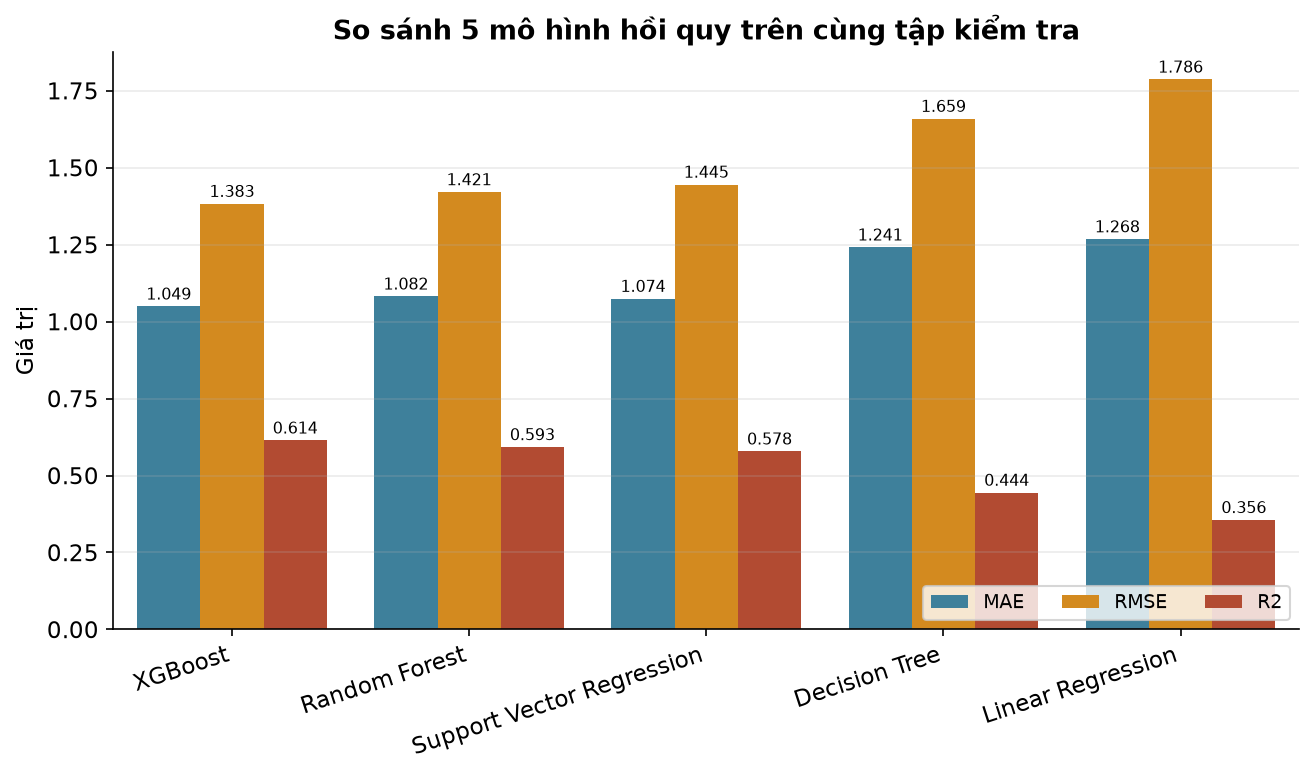

Mô hình tốt nhất theo R²: XGBoost
MAE giảm từ 1.8587 (cơ sở) xuống 1.0493 tỷ VNĐ — cải thiện 43.5%


In [27]:
viz.plot_model_comparison(
    results, ["MAE", "RMSE", "R2"], "hou_model_comparison",
    "So sánh 5 mô hình hồi quy trên cùng tập kiểm tra",
)
show("hou_model_comparison", width=820)

best_name = results.iloc[0]["Model"]
best_model = fitted[best_name]
best_mae = results.iloc[0]["MAE"]

print(f"Mô hình tốt nhất theo R²: {best_name}")
print(f"MAE giảm từ {base_metrics['MAE']:.4f} (cơ sở) xuống {best_mae:.4f} tỷ VNĐ "
      f"— cải thiện {1 - best_mae / base_metrics['MAE']:.1%}")

**Nhận xét.**

1. **Cả năm mô hình đều vượt xa mô hình cơ sở** — R² từ khoảng −0,00 lên tới
   0,61. Việc học mang lại giá trị rõ rệt và đo được bằng tiền: sai số trung bình
   giảm khoảng 0,8 tỷ đồng mỗi căn.
2. **XGBoost thắng**, Random Forest và SVR bám sát. Thứ tự này ngược với bài toán
   1, nơi các mô hình tổ hợp thua KNN — khác biệt nằm ở **quy mô dữ liệu**: 21.764
   quan sát huấn luyện đủ để boosting phát huy, còn 552 quan sát thì không.
3. **Linear Regression xếp cuối** với R² ≈ 0,36, đúng như Mục 6 dự báo từ ma trận
   tương quan. Bài toán này phi tuyến về bản chất.
4. **Khoảng cách giữa ba mô hình dẫn đầu rất hẹp** (R² chênh dưới 0,04). Điều này
   gợi ý rằng cả ba đã tiệm cận **trần thông tin của biểu diễn hiện có**, và cải
   thiện tiếp phải đến từ dữ liệu tốt hơn chứ không phải thuật toán mạnh hơn —
   một kết luận mà Mục 17 và Mục 21 khai thác thêm.

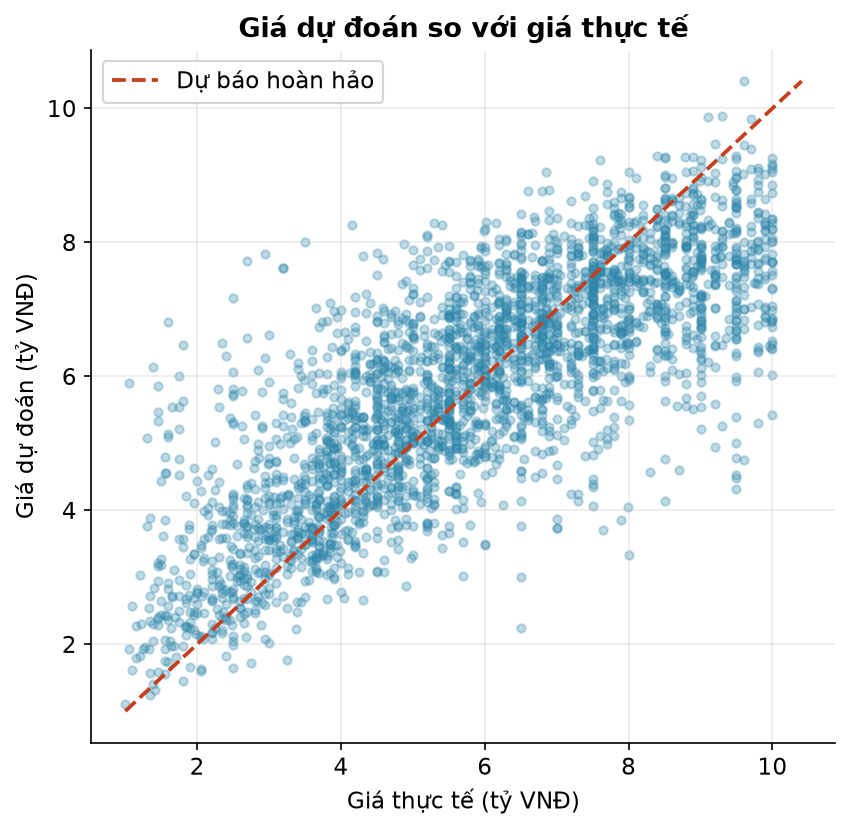

In [28]:
viz.plot_prediction_scatter(y_test, best_model.predict(X_test), "hou_pred_vs_true")
show("hou_pred_vs_true", width=680)

Biểu đồ giá dự đoán so với giá thật cho thấy đám mây điểm **thoải hơn đường
chéo**: ở vùng giá thấp mô hình dự đoán cao hơn thực tế, ở vùng giá cao thì thấp
hơn. Ô dưới đây định lượng hiện tượng đó bằng cách chia tập kiểm tra thành năm
phân khúc giá bằng nhau và đo độ chệch trung bình trong từng phân khúc.

In [29]:
resid = pd.DataFrame({"Giá thật": y_test.values,
                      "Giá dự đoán": best_model.predict(X_test)})
resid["Sai số"] = resid["Giá dự đoán"] - resid["Giá thật"]
resid["Phân khúc"] = pd.qcut(
    resid["Giá thật"], 5,
    labels=["Q1 · rẻ nhất", "Q2", "Q3 · giữa", "Q4", "Q5 · đắt nhất"],
)

bang_sai_so = resid.groupby("Phân khúc", observed=True).agg(
    **{
        "Số căn": ("Giá thật", "size"),
        "Giá thật TB": ("Giá thật", "mean"),
        "Giá dự đoán TB": ("Giá dự đoán", "mean"),
        "Độ chệch TB": ("Sai số", "mean"),
        "MAE": ("Sai số", lambda s: s.abs().mean()),
    }
).round(3)
bang_sai_so

,Số căn,Giá thật TB,Giá dự đoán TB,Độ chệch TB,MAE
Phân khúc,,,,,
Q1 · rẻ nhất,1089,2.685,3.734,1.049,1.158
Q2,1114,4.503,5.150,0.647,0.937
Q3 · giữa,1133,5.919,6.161,0.242,0.789
Q4,1030,7.237,6.851,-0.386,0.838
Q5 · đắt nhất,1076,8.977,7.493,-1.484,1.534


Bài toán hồi quy không có đường cong ROC, nhưng câu hỏi mà ROC trả lời cho
bài phân lớp — *mô hình sai theo kiểu gì, chứ không phải sai bao nhiêu* —
thì vẫn nguyên giá trị. Bốn bảng dưới đây trả lời câu ấy.

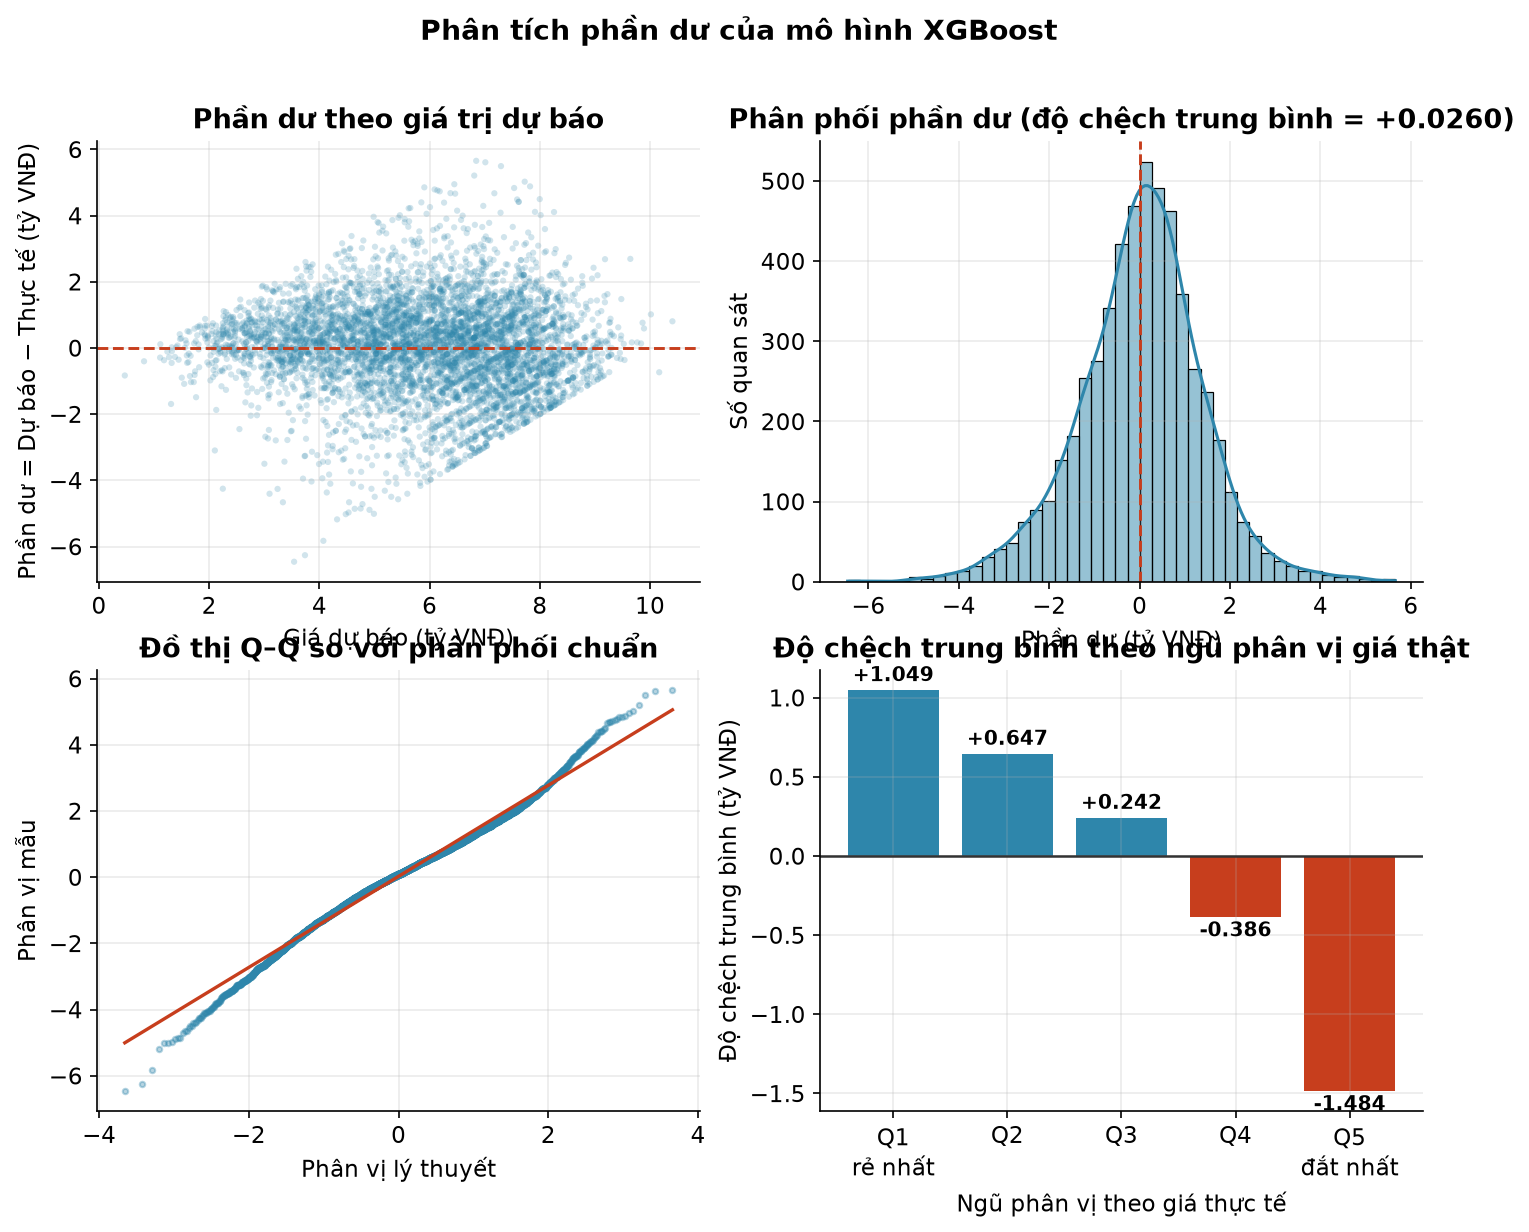

In [30]:
viz.plot_residual_analysis(
    y_test, best_model.predict(X_test), "hou_residual_analysis",
    f"Phân tích phần dư của mô hình {results.iloc[0]['Model']}")
show("hou_residual_analysis", width=880)

**Bảng thứ tư là phát hiện quan trọng nhất của cả notebook này.** Độ chệch
không phân bố ngẫu nhiên quanh 0 mà **giảm đơn điệu** theo phân khúc giá:
định giá **vượt** khoảng 1,05 tỷ ở nhóm rẻ nhất và định giá **hụt** khoảng
1,48 tỷ ở nhóm đắt nhất.

Hai nguyên nhân cộng dồn: hồi quy về trung bình, và việc mô hình cây
**không ngoại suy** được ra ngoài khoảng giá trị đã thấy lúc huấn luyện.

Hệ quả phải nói rõ với người dùng, chứ không được giấu sau một con số MAE
gộp: với bất động sản cao cấp, con số hệ thống đưa ra là **cận dưới**.

**Đây là phát hiện đáng chú ý nhất của bài toán 2.** Độ chệch **đơn điệu** từ
dương lớn ở phân khúc rẻ nhất sang âm lớn ở phân khúc đắt nhất: mô hình định giá
nhà rẻ **cao hơn** thực tế khoảng 1 tỷ, và định giá nhà đắt **thấp hơn** thực tế
khoảng 1,5 tỷ. Sai số ở hai đầu dải lớn gần gấp đôi sai số ở giữa.

Đây không phải lỗi cài đặt mà là hiện tượng **hồi quy về trung bình** (regression
to the mean) ở dạng kinh điển, có hai nguyên nhân cộng hưởng:

1. **Hàm mất mát bình phương kéo dự đoán về trung tâm.** Khi biểu diễn không đủ
   thông tin để phân biệt chắc chắn một căn nhà là rẻ hay đắt, phương án tối
   thiểu hoá bình phương sai số là đoán gần giá trị trung bình. Đây là hành vi
   **tối ưu** theo đúng hàm mục tiêu — không phải hỏng.
2. **Cây quyết định không ngoại suy.** Dự đoán của mô hình dựa trên cây luôn là
   trung bình của các quan sát trong một lá, nên **không bao giờ vượt ra ngoài**
   dải giá đã thấy khi huấn luyện, và ở sát biên thì luôn bị kéo vào trong.

Hệ quả thực tiễn cần nói rõ với người dùng: hệ thống đáng tin nhất ở phân khúc
giữa và **có xu hướng đánh giá thấp bất động sản cao cấp một cách có hệ thống**.
Với người bán ở phân khúc cao, con số ước lượng nên đọc là *cận dưới*, không phải
giá kỳ vọng.

**Kiểm chứng trên tập ngoại kiểm.**

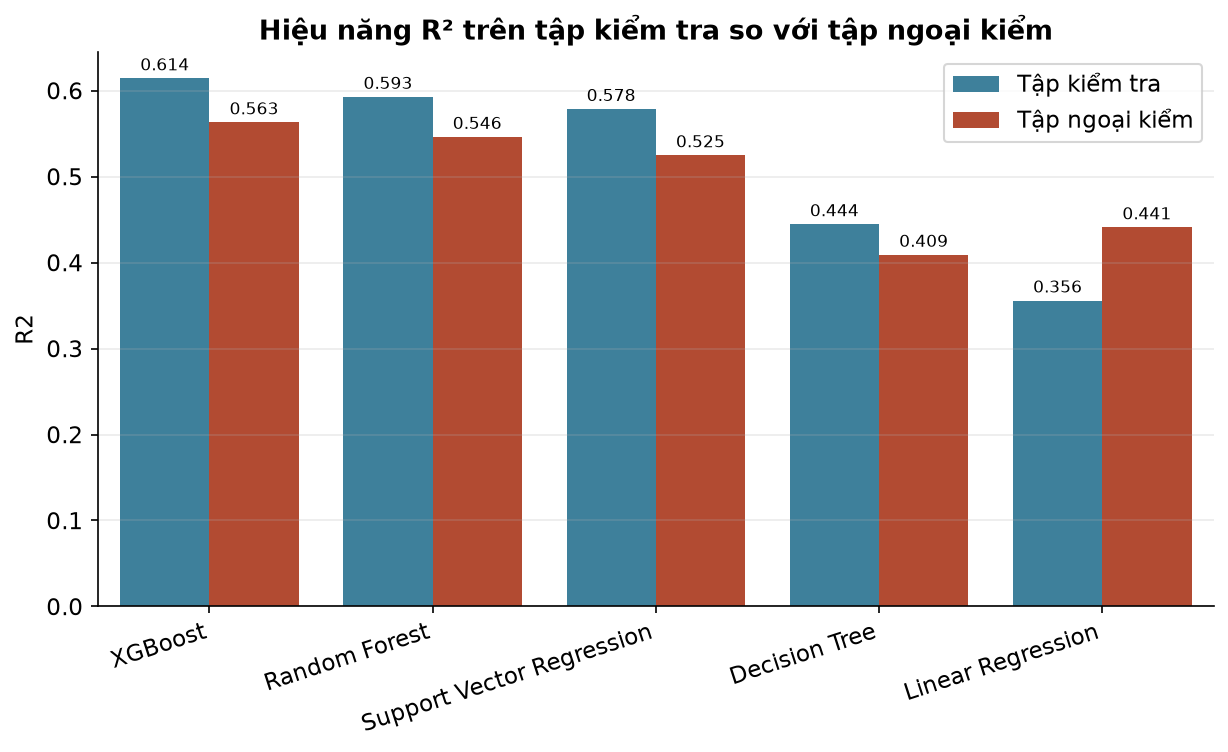

,Model,MAE,MSE,RMSE,R2
0,XGBoost,1.1070,2.1465,1.4651,0.5629
1,Random Forest,1.1310,2.2297,1.4932,0.5460
2,Support Vector Regression,1.1302,2.3345,1.5279,0.5246
3,Linear Regression,1.2935,2.7459,1.6571,0.4408
4,Decision Tree,1.2736,2.9030,1.7038,0.4088


In [31]:
ood_results = ev.compare_regressors(fitted, X_ood, y_ood)
viz.plot_ood_comparison(
    results, ood_results, "R2", "hou_ood_comparison",
    "Hiệu năng R² trên tập kiểm tra so với tập ngoại kiểm",
)
show("hou_ood_comparison", width=760)
ood_results.round(4)

Với 3.023 quan sát ngoại kiểm — gấp 39 lần bài toán 1 — kết quả ổn định hơn hẳn
và cho phép kết luận chắc chắn hơn về khả năng tổng quát hoá.

---

## 16. Thực nghiệm 2 — Khảo sát siêu tham số

**Siêu tham số khảo sát:** `max_depth` của Random Forest.

**Giả thuyết.** Độ sâu tối đa điều khiển đánh đổi độ chệch – phương sai. Cây quá
nông không đủ sức mô tả quan hệ phi tuyến (độ chệch cao); cây quá sâu ghi nhớ
từng tin đăng (phương sai cao). Tồn tại một độ sâu tối ưu ở giữa.

**Thiết kế.** Chỉ `max_depth` thay đổi. Số cây cố định 120, `min_samples_leaf=5`,
cùng tập dữ liệu, cùng hạt giống.

In [32]:
from sklearn.ensemble import RandomForestRegressor

depths = [4, 6, 8, 12, 16, 20, 24, 28, 32, 40]
depth_sweep = ev.sweep_hyperparameter(
    lambda d: tr.make_pipeline(
        make_prep(),
        RandomForestRegressor(n_estimators=120, max_depth=d, min_samples_leaf=5,
                              random_state=cfg.RANDOM_STATE, n_jobs=-1),
    ),
    depths, X_train, y_train, X_test, y_test,
    ev.regression_metrics, "R2", "max_depth",
)
depth_sweep.round(4)

,max_depth,MAE,MSE,RMSE,R2
0,4,1.4240,3.1144,1.7648,0.3712
1,6,1.3098,2.6750,1.6355,0.4600
2,8,1.2275,2.4043,1.5506,0.5146
3,12,1.1376,2.1525,1.4671,0.5654
4,16,1.0947,2.0497,1.4317,0.5862
5,20,1.0774,2.0124,1.4186,0.5937
6,24,1.0716,2.0040,1.4156,0.5954
7,28,1.0704,2.0041,1.4157,0.5954
8,32,1.0705,2.0047,1.4159,0.5953
9,40,1.0703,2.0047,1.4159,0.5953


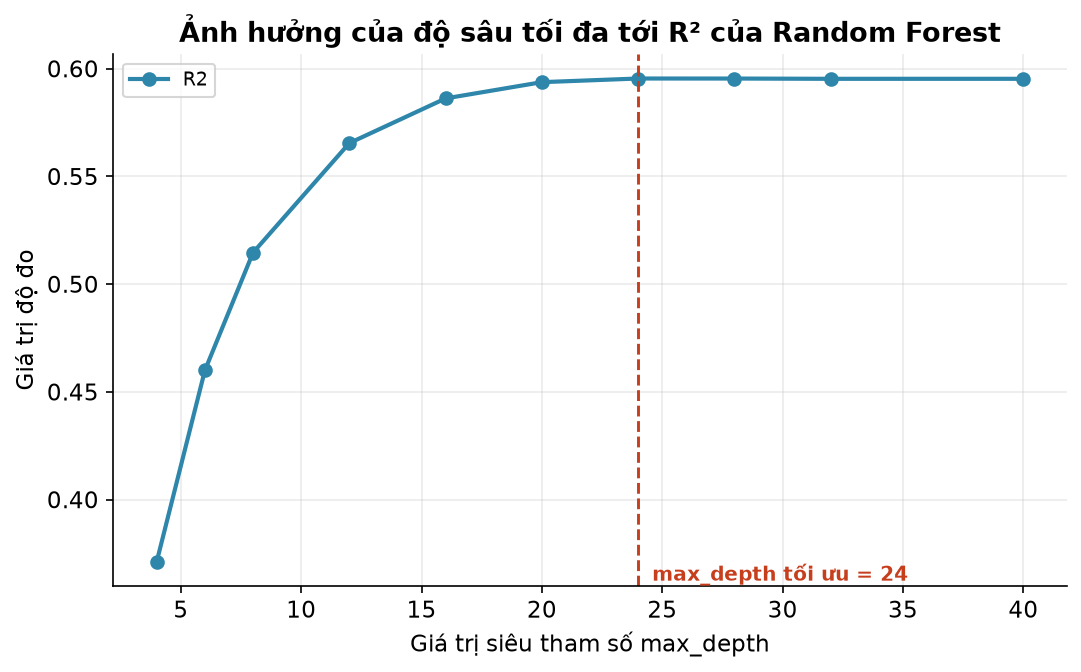

Độ sâu tối ưu theo R²: max_depth = 24
Nằm ở đầu mút dải khảo sát? Không — cực trị hợp lệ
R² tại độ sâu tối ưu : 0.5954
R² tại độ sâu 40     : 0.5953  (chênh +0.0001)


In [33]:
viz.plot_hyperparameter_sweep(
    depth_sweep, "max_depth", ["R2"], "hou_depth_sweep",
    "Ảnh hưởng của độ sâu tối đa tới R² của Random Forest",
)
show("hou_depth_sweep", width=760)

best_depth = int(depth_sweep.loc[depth_sweep["R2"].idxmax(), "max_depth"])
r2_at_best = depth_sweep["R2"].max()
r2_at_end = depth_sweep.iloc[-1]["R2"]

print(f"Độ sâu tối ưu theo R²: max_depth = {best_depth}")
print(f"Nằm ở đầu mút dải khảo sát? "
      f"{'CÓ — cần nới dải' if best_depth in (depths[0], depths[-1]) else 'Không — cực trị hợp lệ'}")
print(f"R² tại độ sâu tối ưu : {r2_at_best:.4f}")
print(f"R² tại độ sâu 40     : {r2_at_end:.4f}  (chênh {r2_at_best - r2_at_end:+.4f})")

**Kết luận thực nghiệm 2.** Đường cong tăng nhanh tới độ sâu khoảng 20 rồi **đi
ngang**, không giảm. Đây là điểm khác biệt đáng chú ý so với lý thuyết sách giáo
khoa: người ta thường trông đợi R² **giảm** khi cây quá sâu vì học thuộc.

Nguyên nhân là `min_samples_leaf=5` — ràng buộc này chặn cây mọc tới lá chỉ chứa
một quan sát, nên tăng `max_depth` quá một mức nào đó **không còn tác dụng gì**:
cây đã dừng vì hết mẫu chứ không vì chạm giới hạn độ sâu. Nói cách khác, hai siêu
tham số này **tương tác** với nhau, và khảo sát một chiều chỉ nhìn thấy một lát
cắt của bề mặt hiệu năng.

Bài học phương pháp: khi đường cong siêu tham số đi ngang thay vì tạo đỉnh rõ,
hãy tìm xem có ràng buộc nào khác đang chi phối trước khi kết luận.

> **Cảnh báo về cực trị đầu mút.** Ở lần chạy đầu, dải khảo sát chỉ tới 24 và cực
> trị rơi đúng vào giá trị cuối — chưa đủ căn cứ kết luận. Dải được nới tới 40 mới
> xác nhận được đường cong đã bão hoà. Ô kiểm tra ở trên tự động hoá bước rà này.

---

## 17. Thực nghiệm 3 — Ảnh hưởng của biểu diễn dữ liệu

**Đây là thực nghiệm trung tâm của bài tập.** Câu hỏi: *cùng một thuật toán, đổi
cách biểu diễn dữ liệu thì kết quả thay đổi bao nhiêu?*

**Thiết kế.** Thuật toán cố định là Random Forest (120 cây, `max_depth=16`,
`min_samples_leaf=5`) với siêu tham số y hệt nhau ở cả ba phương án. Thứ duy nhất
thay đổi là ma trận đặc trưng $X$.

| Phương án | Nội dung |
|---|---|
| Chỉ đặc trưng định lượng | Bỏ hoàn toàn thông tin vị trí, pháp lý, hướng nhà |
| Định lượng + định danh, chưa thiết kế | Thêm 5 biến định danh qua mã hoá one-hot |
| Đầy đủ + đặc trưng thiết kế | Thêm 3 đặc trưng thiết kế phái sinh |

In [34]:
X_plain, y_plain, _ = prep.prepare_housing(engineered=False)
num_p, cat_p = prep.housing_column_types(X_plain)
Xp_tr, Xp_te, _, yp_tr, yp_te, _ = tr.three_way_split(X_plain, y_plain)

X_num_only = X[numeric]
Xn_tr, Xn_te, _, yn_tr, yn_te, _ = tr.three_way_split(X_num_only, y)

variants = {
    "Chỉ đặc trưng định lượng": (Xn_tr, Xn_te, yn_tr, yn_te, numeric, []),
    "Định lượng + định danh, chưa thiết kế": (Xp_tr, Xp_te, yp_tr, yp_te, num_p, cat_p),
    "Đầy đủ + đặc trưng thiết kế": (X_train, X_test, y_train, y_test, numeric, categorical),
}

rep_rows = []
for label, (Xtr_, Xte_, ytr_, yte_, nums, cats) in variants.items():
    pipe = tr.make_pipeline(
        tr.mixed_preprocessor(nums, cats),
        RandomForestRegressor(n_estimators=120, max_depth=16, min_samples_leaf=5,
                              random_state=cfg.RANDOM_STATE, n_jobs=-1),
    )
    pipe.fit(Xtr_, ytr_)
    rep_rows.append({"Representation": label,
                     **ev.regression_metrics(yte_, pipe.predict(Xte_))})

rep_results = (pd.DataFrame(rep_rows)
                 .sort_values("R2", ascending=False)
                 .reset_index(drop=True))
rep_results.round(4)

,Representation,MAE,MSE,RMSE,R2
0,"Định lượng + định danh, chưa thiết kế",1.0932,2.0294,1.4246,0.5903
1,Đầy đủ + đặc trưng thiết kế,1.0947,2.0497,1.4317,0.5862
2,Chỉ đặc trưng định lượng,1.4388,3.2988,1.8163,0.3340


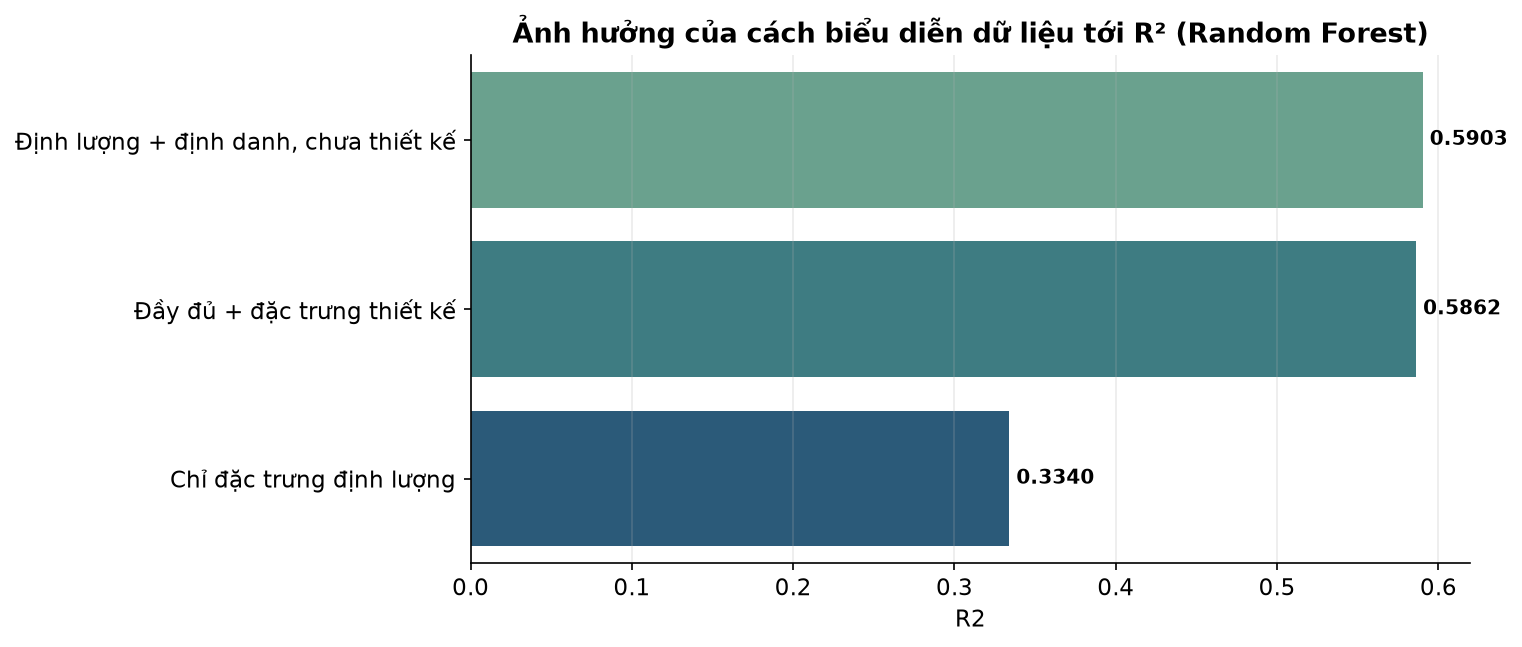

Bỏ hết đặc trưng định danh: R² 0.5903 → 0.3340 (mất 43.4% năng lực giải thích)


In [35]:
viz.plot_representation_comparison(
    rep_results, "R2", "hou_representation",
    "Ảnh hưởng của cách biểu diễn dữ liệu tới R² (Random Forest)",
)
show("hou_representation", width=760)

r2 = rep_results.set_index("Representation")["R2"]
r2_num_only = r2["Chỉ đặc trưng định lượng"]
r2_best = r2.max()
print(f"Bỏ hết đặc trưng định danh: R² {r2_best:.4f} → {r2_num_only:.4f} "
      f"(mất {(r2_best - r2_num_only) / r2_best:.1%} năng lực giải thích)")

**Hai kết luận, một trong đó đi ngược kỳ vọng ban đầu.**

**(1) Biến định danh là nhóm thông tin quyết định.** Bỏ hết vị trí hành chính,
tình trạng pháp lý và hướng nhà làm R² sụt khoảng **43%** — mức thiệt hại lớn hơn
mọi khác biệt giữa các thuật toán ở Mục 15 cộng lại. Kết quả này xác nhận chính
thức giả thuyết đã hình thành từ Mục 7.4, và nó khớp với hiểu biết nghiệp vụ:
trong định giá bất động sản, *vị trí* là yếu tố đầu tiên.

**(2) Đặc trưng thiết kế *không* cải thiện Random Forest** — hai phương án cuối
gần như bằng nhau, thậm chí phương án chưa thiết kế còn nhỉnh hơn chút ít. Đây là **kết quả âm tính** và
cần được báo cáo trung thực thay vì che đi.

Giải thích: `Total_Area = Area × Floors` là một **tương tác nhân**, mà cây quyết
định vốn đã biểu diễn được bằng cách chia nút lồng nhau (`Area > a` **rồi**
`Floors > f`). Đặc trưng thiết kế vì thế không thêm thông tin mới cho cây, chỉ
thêm chiều cho không gian tìm kiếm — và ở mỗi nút, Random Forest lấy mẫu ngẫu
nhiên một tập con đặc trưng, nên chiều thừa làm loãng xác suất chọn trúng đặc
trưng thật sự tốt.

Đối chiếu với bài toán 1 làm rõ nguyên tắc: ở đó đặc trưng thiết kế **có** cải
thiện, vì mô hình được dùng là Logistic Regression — mô hình tuyến tính **không**
tự tạo được số hạng tương tác. Vậy nên:

> **Giá trị của một đặc trưng thiết kế không nằm ở bản thân nó, mà ở khoảng cách
> giữa thứ nó mã hoá và thứ thuật toán tự biểu diễn được.** Cùng một đặc trưng có
> thể rất giá trị với mô hình tuyến tính và hoàn toàn thừa với mô hình dựa trên
> cây.

Đặc trưng thiết kế vẫn được **giữ lại** trong hệ thống triển khai, vì XGBoost và
các mô hình tuyến tính trong danh mục vẫn dùng đến chúng, và vì `Room_Density` /
`Frontage_Ratio` giúp phần diễn giải kết quả cho người dùng dễ hiểu hơn.

---

## 18. Mô hình cuối cùng

**XGBoost** được chọn triển khai: dẫn đầu cả ba độ đo (MAE, RMSE, R²) và huấn
luyện nhanh hơn SVR khoảng hai bậc, điều quan trọng khi cần huấn luyện lại định
kỳ theo dữ liệu thị trường mới.

**Kiểm tra tính tái lập.** Ô dưới đây nạp lại pipeline mà `run_pipeline.py` đã
lưu xuống `models/` và đối chiếu với mô hình vừa huấn luyện trong notebook. Hai
bên phải cho dự đoán trùng khớp hoàn toàn — bằng chứng cho yêu cầu R14 và bảo đảm
ứng dụng web dùng đúng mô hình notebook mô tả.

In [36]:
saved = tr.load_model("housing_best.joblib")
live = fitted["XGBoost"]

p_saved = saved.predict(X_test)
p_live = live.predict(X_test)

print(f"Tệp mô hình đã lưu : models/housing_best.joblib")
print(f"Dự đoán trùng khớp : {np.allclose(p_saved, p_live)}")
print(f"Sai lệch tối đa    : {np.abs(p_saved - p_live).max():.2e} tỷ VNĐ")

final_model = saved

Tệp mô hình đã lưu : models/housing_best.joblib
Dự đoán trùng khớp : True
Sai lệch tối đa    : 0.00e+00 tỷ VNĐ


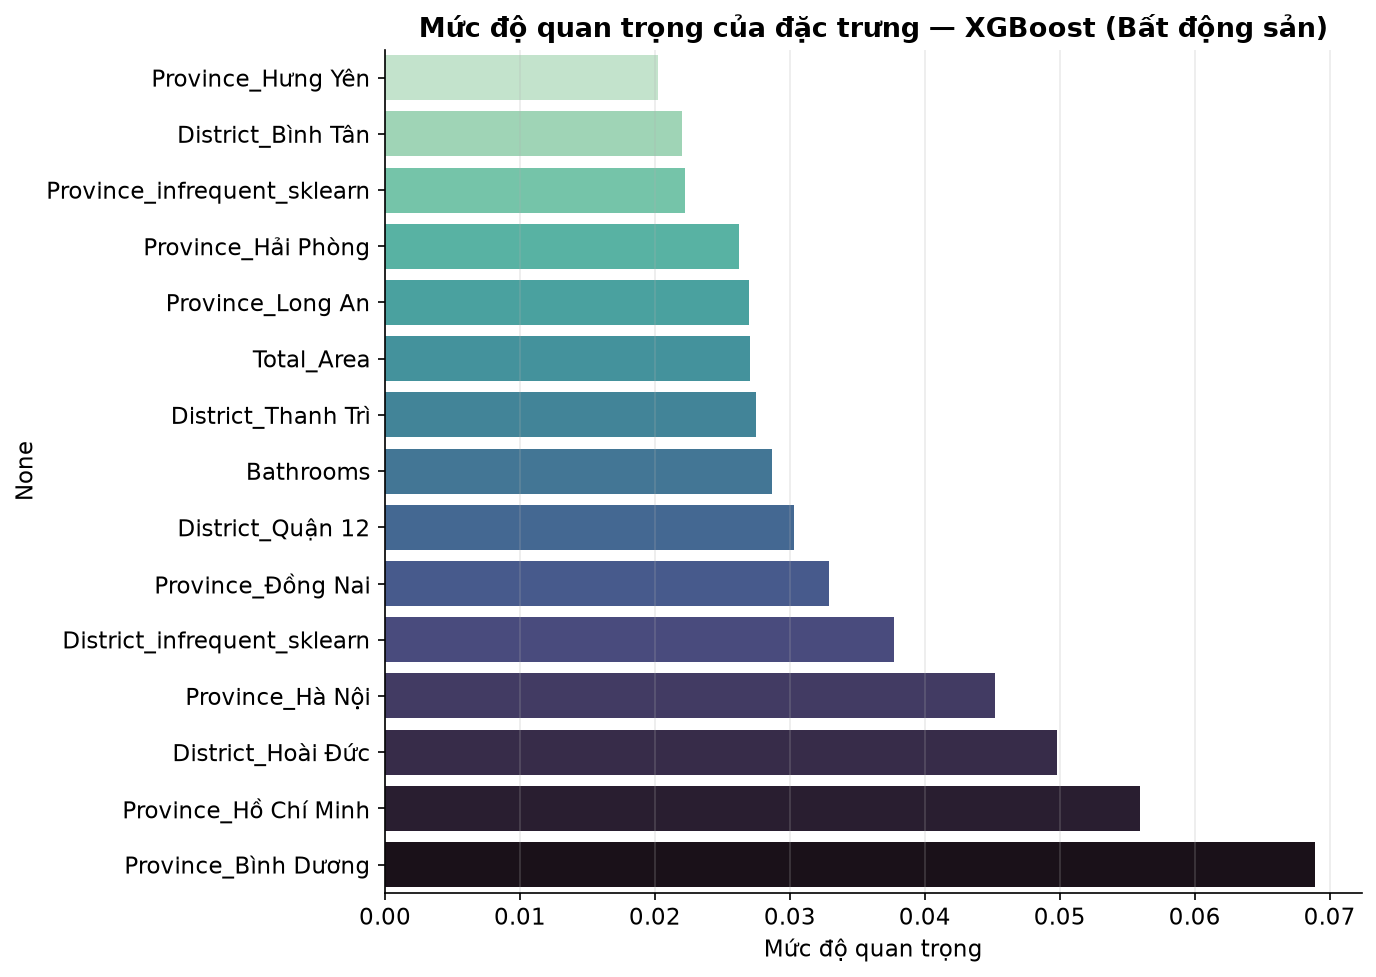

In [37]:
viz.plot_feature_importance(
    final_model, "hou_feature_importance",
    title="Mức độ quan trọng của đặc trưng — XGBoost (Bất động sản)",
)
show("hou_feature_importance", width=760)

Biểu đồ này bổ sung một góc nhìn cho Thực nghiệm 3: các cột one-hot của
`Province` và `District` chiếm vị trí cao, nhất quán với kết luận rằng vị trí
hành chính là nhóm thông tin quyết định.

---

## 19. Ứng dụng

Ô dưới đây mô phỏng đúng đường đi của một yêu cầu định giá: người dùng khai báo
thuộc tính căn nhà ở dạng **thô** (kể cả thiếu trường), hệ thống trả về giá ước
lượng kèm khoảng sai số và so sánh với mặt bằng giá cùng tỉnh/thành.

Toàn bộ chuỗi *điền khuyết → thiết kế đặc trưng → chuẩn hoá → mã hoá one-hot*
nằm bên trong pipeline đã lưu, nên người dùng không cần biết gì về biểu diễn.
Đây là điều kiện để yêu cầu R11 được đáp ứng mà không phải chép logic sang ứng
dụng web.

In [38]:
gia_trung_vi_tinh = y.groupby(X["Province"]).median()
mae_he_thong = float(results.iloc[0]["MAE"])

DAC_TRUNG_THIET_KE = ["Total_Area", "Room_Density", "Frontage_Ratio"]
DINH_LUONG_GOC = [c for c in numeric if c not in DAC_TRUNG_THIET_KE]


def dinh_gia(**thuoc_tinh) -> dict:
    """Chạy một hồ sơ căn nhà thô qua toàn bộ hệ thống định giá."""
    record = pd.DataFrame([thuoc_tinh])

    # Trường người dùng bỏ trống được điền đúng theo quy tắc của bước làm sạch:
    # định lượng lấy trung vị tập huấn luyện, định danh thành hạng mục "Không rõ".
    for col in DINH_LUONG_GOC:
        if col not in record.columns or record[col].isna().all():
            record[col] = X_train[col].median()
    for col in categorical:
        if col not in record.columns:
            record[col] = "Không rõ"
        record[col] = record[col].fillna("Không rõ")

    # Đặc trưng thiết kế tính SAU khi điền — giống hệt thứ tự lúc huấn luyện.
    record = prep.add_housing_features(record)[X.columns]

    gia = float(final_model.predict(record)[0])
    tinh = thuoc_tinh.get("Province", "Không rõ")
    mat_bang = float(gia_trung_vi_tinh.get(tinh, y.median()))

    return {
        "Giá ước lượng (tỷ VNĐ)": round(gia, 3),
        "Khoảng tin cậy": f"{max(gia - mae_he_thong, 0):.2f} – {gia + mae_he_thong:.2f}",
        "Trung vị cùng tỉnh/thành": round(mat_bang, 3),
        "So với mặt bằng": f"{gia / mat_bang - 1:+.1%}",
    }


can_nha = {
    "Nhà phố Hà Nội": dict(
        Province="Hà Nội", District="Cầu Giấy", Area=65.0, Frontage=4.5,
        **{"Access Road": 6.0}, Floors=5.0, Bedrooms=4.0, Bathrooms=4.0,
        **{"House direction": "Đông - Nam", "Legal status": "Have certificate",
           "Furniture state": "Full"}),
    "Nhà TP.HCM": dict(
        Province="Hồ Chí Minh", District="Bình Thạnh", Area=48.0, Frontage=4.0,
        **{"Access Road": 5.0}, Floors=3.0, Bedrooms=3.0, Bathrooms=3.0,
        **{"House direction": "Nam", "Legal status": "Have certificate",
           "Furniture state": "Basic"}),
    "Nhà tỉnh lẻ": dict(
        Province="Bình Dương", District="Thuận An", Area=90.0, Frontage=5.0,
        **{"Access Road": 8.0}, Floors=1.0, Bedrooms=3.0, Bathrooms=2.0,
        **{"House direction": "Bắc", "Legal status": "Have certificate",
           "Furniture state": "Basic"}),
}

pd.DataFrame({ten: dinh_gia(**hs) for ten, hs in can_nha.items()}).T

,Giá ước lượng (tỷ VNĐ),Khoảng tin cậy,Trung vị cùng tỉnh/thành,So với mặt bằng
Nhà phố Hà Nội,9.322,8.27 – 10.37,6.1,+52.8%
Nhà TP.HCM,6.543,5.49 – 7.59,6.3,+3.9%
Nhà tỉnh lẻ,3.205,2.16 – 4.25,3.6,-11.0%


Đáng chú ý nhất là cặp thứ nhất và thứ ba: căn ở Bình Dương có **diện tích lớn
hơn** căn ở Hà Nội (90 m² so với 65 m²) nhưng được định giá chỉ bằng khoảng một
phần ba. Vị trí lấn át diện tích — đúng như Thực nghiệm 3 (Mục 17) đã đo được khi
bỏ hết biến định danh làm R² sụt 43%.

**Kiểm tra khả năng xử lý hồ sơ thiếu dữ liệu** — tình huống rất phổ biến vì
người đăng tin hiếm khi khai đủ mọi trường:

### 19.1 Từ giá dự báo tới hạn mức vay và hạ tầng quanh đó

Một mức giá vẫn chưa trả lời được câu hỏi thật của người mua: *vay được bao
nhiêu, mỗi tháng trả bao nhiêu, thu nhập bao nhiêu thì gánh nổi*. Ô dưới đây
gọi danh mục tài chính trong `src/kg/catalog_urban.py`, nơi khoản trả góp
được tính bằng **công thức niên kim** chứ không phải ước lượng:

$$ M = P \cdot \frac{r}{1 - (1+r)^{-n}} $$

với $P$ là dư nợ gốc, $r$ là lãi suất tháng và $n$ là tổng số kỳ trả.

In [39]:
from src.kg import catalog_urban as urban
from src.kg.ontology import classify_segment

gia_du_bao = 8.42                     # tin đăng #23933 ở ví dụ trên
phan_khuc = classify_segment(gia_du_bao)
ho_so = urban.ho_so_tai_chinh(gia_du_bao, phan_khuc)

pd.DataFrame([
    {"Khoản mục": "Giá định giá",        "Giá trị": urban.ty_dong(ho_so["gia_dinh_gia"])},
    {"Khoản mục": "Tỷ lệ cho vay (LTV)", "Giá trị": f"{ho_so['ltv']:.0%}"},
    {"Khoản mục": "Hạn mức vay",         "Giá trị": urban.ty_dong(ho_so["han_muc_vay"])},
    {"Khoản mục": "Vốn tự có cần có",    "Giá trị": urban.ty_dong(ho_so["von_tu_co"])},
    {"Khoản mục": "Trả góp hằng tháng",  "Giá trị": urban.ty_dong(ho_so["tra_gop_thang"])},
    {"Khoản mục": "Tổng tiền lãi",       "Giá trị": urban.ty_dong(ho_so["tong_tien_lai"])},
    {"Khoản mục": "Thu nhập tối thiểu",  "Giá trị": urban.ty_dong(ho_so["thu_nhap_toi_thieu"])},
])

,Khoản mục,Giá trị
0,Giá định giá,8.42 tỷ đ
1,Tỷ lệ cho vay (LTV),70%
2,Hạn mức vay,5.89 tỷ đ
3,Vốn tự có cần có,2.53 tỷ đ
4,Trả góp hằng tháng,47.5 triệu đ
5,Tổng tiền lãi,8.34 tỷ đ
6,Thu nhập tối thiểu,0.12 tỷ đ


Con số đáng chú ý là **tổng tiền lãi**: với kỳ hạn 25 năm ở mức lãi suất
8,5%/năm, tiền lãi vượt cả dư nợ gốc. Đây là thông tin mà bảng quảng cáo
gói vay hiếm khi đặt cạnh con số trả góp hằng tháng, nên hệ thống hiển thị
nó tường minh.

Sơ đồ dưới đây là lược đồ năm tầng của Đồ thị Tri thức Đô thị – Tài chính,
vẽ từ chính `ontology.KG_LAYERS`.

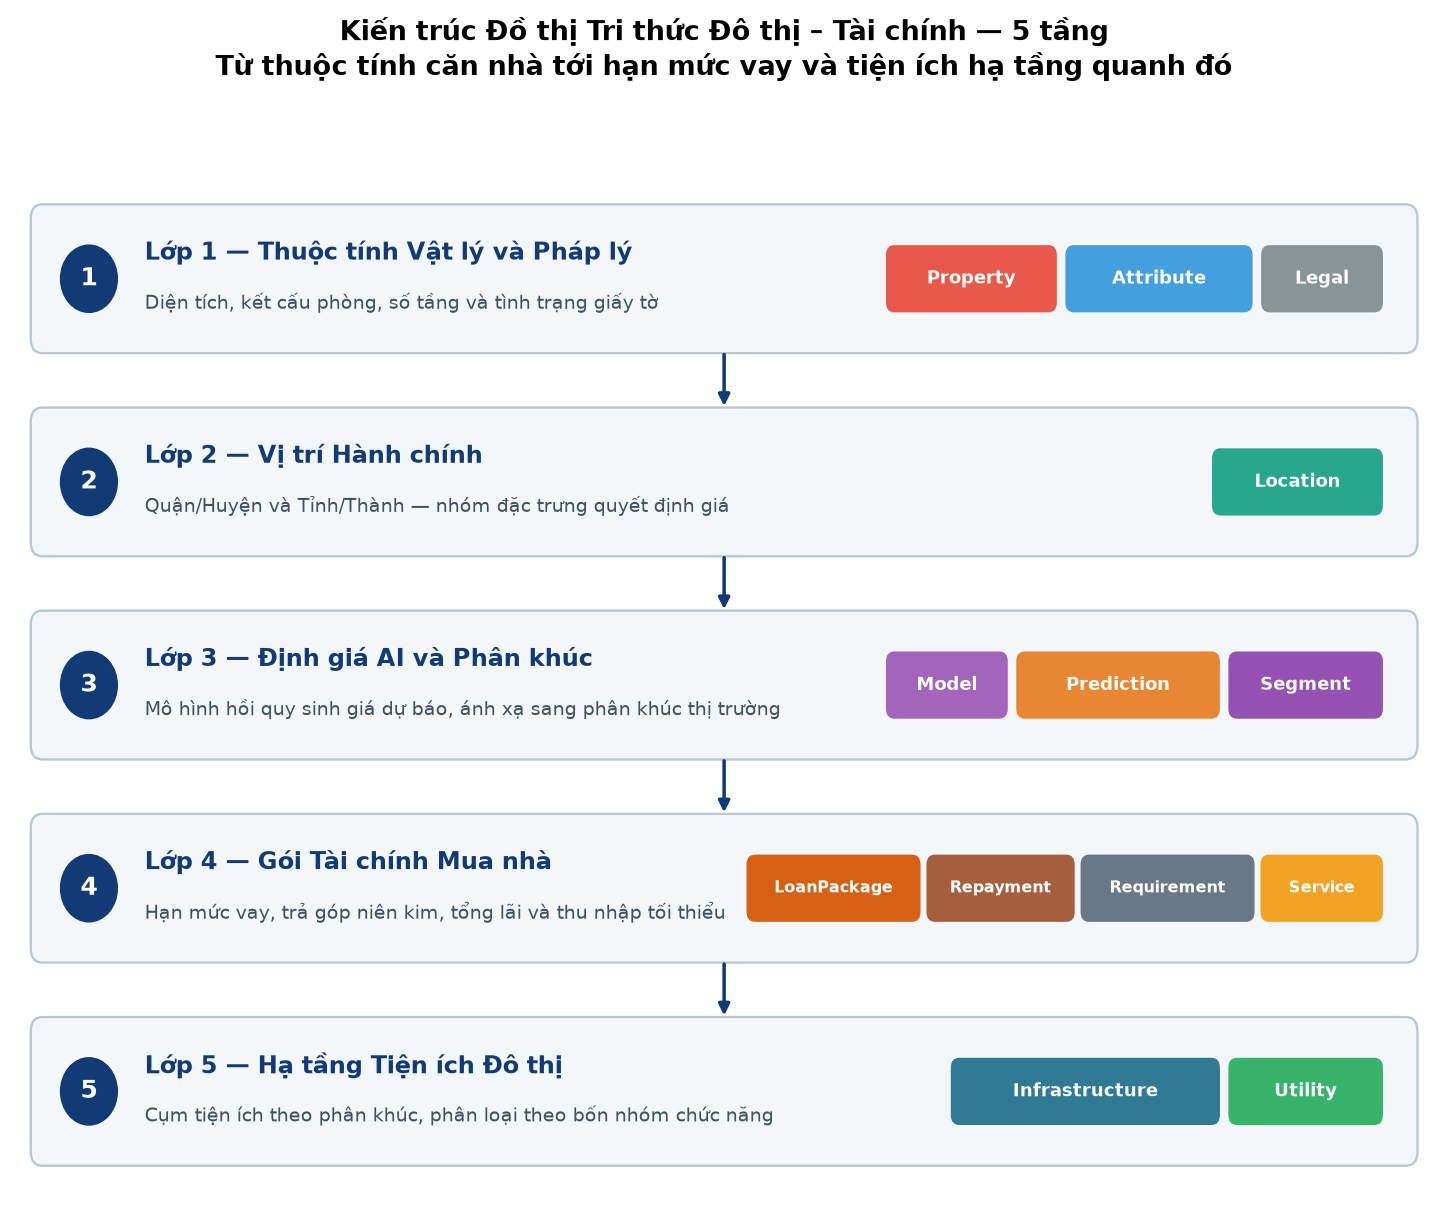

In [40]:
from src.kg import ontology as ont

viz.plot_kg_architecture(
    ont.KG_LAYERS["property"], ont.NODE_COLOURS, "fig_kg_architecture_property",
    "Kiến trúc Đồ thị Tri thức Đô thị – Tài chính — 5 tầng",
    "Từ thuộc tính căn nhà tới hạn mức vay và tiện ích hạ tầng quanh đó")
show("fig_kg_architecture_property", width=880)

In [41]:
ho_so_thieu = dict(
    Province="Hà Nội", District="Cầu Giấy", Area=65.0,
    Floors=5.0, Bedrooms=4.0, Bathrooms=4.0,
)
pd.DataFrame(
    [dinh_gia(**ho_so_thieu)],
    index=["Thiếu mặt tiền, đường vào, hướng nhà, pháp lý, nội thất"],
)

,Giá ước lượng (tỷ VNĐ),Khoảng tin cậy,Trung vị cùng tỉnh/thành,So với mặt bằng
"Thiếu mặt tiền, đường vào, hướng nhà, pháp lý, nội thất",9.011,7.96 – 10.06,6.1,+47.7%


---

## 20. Minh hoạ hệ thống — đường đi trọn vẹn của một quan sát

Mục này lần theo **một** tin đăng qua đúng sáu tầng của sơ đồ ở Mục 2, in ra
trạng thái dữ liệu sau mỗi tầng (yêu cầu R12).

In [42]:
i = 0
raw_record = X_test.iloc[[i]]
gia_that = float(y_test.iloc[i])

print("─" * 74)
print("TẦNG 1-2 · ENVIRONMENT → INPUT DATA — thuộc tính căn nhà như người đăng khai")
print("─" * 74)
print(raw_record.T.rename(columns={raw_record.index[0]: "Giá trị"}).to_string())

──────────────────────────────────────────────────────────────────────────
TẦNG 1-2 · ENVIRONMENT → INPUT DATA — thuộc tính căn nhà như người đăng khai
──────────────────────────────────────────────────────────────────────────
                          Giá trị
Area                         72.0
Frontage                      4.5
Access Road                   6.0
House direction          Không rõ
Floors                        5.0
Bedrooms                      4.0
Bathrooms                     5.0
Legal status     Have certificate
Furniture state          Không rõ
Province              Hồ Chí Minh
District                   Gò Vấp
Total_Area                  360.0
Room_Density                0.125
Frontage_Ratio             0.0625


In [43]:
print("─" * 74)
print("TẦNG 3 · REPRESENTATION — vector số sau chuẩn hoá và mã hoá one-hot")
print("─" * 74)

prep_step = final_model.named_steps["prep"]
x_vector = prep_step.transform(raw_record)
feature_names = list(prep_step.get_feature_names_out())

print(f"Số chiều: {raw_record.shape[1]} cột thô → {x_vector.shape[1]} chiều số")
print(f"  · {len(numeric)} chiều định lượng đã chuẩn hoá")
print(f"  · {x_vector.shape[1] - len(numeric)} chiều nhị phân từ mã hoá one-hot\n")

print(f"{len(numeric)} chiều định lượng sau chuẩn hoá:")
print(pd.Series(x_vector[0][:len(numeric)], index=feature_names[:len(numeric)])
        .round(4).to_string())

active = [feature_names[j] for j in range(len(numeric), x_vector.shape[1])
          if x_vector[0][j] == 1.0]
print(f"\nCác chiều one-hot đang bật ({len(active)}):")
for f in active:
    print(f"  · {f}")

──────────────────────────────────────────────────────────────────────────
TẦNG 3 · REPRESENTATION — vector số sau chuẩn hoá và mã hoá one-hot
──────────────────────────────────────────────────────────────────────────
Số chiều: 14 cột thô → 84 chiều số
  · 9 chiều định lượng đã chuẩn hoá
  · 75 chiều nhị phân từ mã hoá one-hot

9 chiều định lượng sau chuẩn hoá:
num__Area              0.0807
num__Frontage         -0.1559
num__Access Road      -0.1830
num__Floors            1.3103
num__Bedrooms          0.4762
num__Bathrooms         1.4005
num__Total_Area        1.1483
num__Room_Density     -0.0318
num__Frontage_Ratio   -0.3774

Các chiều one-hot đang bật (5):
  · cat__House direction_Không rõ
  · cat__Legal status_Have certificate
  · cat__Furniture state_Không rõ
  · cat__Province_Hồ Chí Minh
  · cat__District_Gò Vấp


In [44]:
print("─" * 74)
print("TẦNG 4-5 · LEARNING MODEL → PREDICTION")
print("─" * 74)

gia_du_doan = float(final_model.predict(raw_record)[0])
sai_so = gia_du_doan - gia_that

print(f"Mô hình         : XGBoost (500 cây, learning_rate = 0.05)")
print(f"Giá dự đoán     : {gia_du_doan:.3f} tỷ VNĐ")
print(f"Giá thật        : {gia_that:.3f} tỷ VNĐ")
print(f"Sai số          : {sai_so:+.3f} tỷ VNĐ ({sai_so / gia_that:+.1%})")
print(f"MAE toàn hệ thống: {mae_he_thong:.3f} tỷ VNĐ")

print("\n" + "─" * 74)
print("TẦNG 6 · APPLICATION — thông tin trả về cho người dùng")
print("─" * 74)
print(f"Giá ước lượng  : {gia_du_doan:.2f} tỷ VNĐ")
print(f"Khoảng tin cậy : {max(gia_du_doan - mae_he_thong, 0):.2f} – "
      f"{gia_du_doan + mae_he_thong:.2f} tỷ VNĐ")

──────────────────────────────────────────────────────────────────────────
TẦNG 4-5 · LEARNING MODEL → PREDICTION
──────────────────────────────────────────────────────────────────────────
Mô hình         : XGBoost (500 cây, learning_rate = 0.05)
Giá dự đoán     : 8.086 tỷ VNĐ
Giá thật        : 7.800 tỷ VNĐ
Sai số          : +0.286 tỷ VNĐ (+3.7%)
MAE toàn hệ thống: 1.049 tỷ VNĐ

──────────────────────────────────────────────────────────────────────────
TẦNG 6 · APPLICATION — thông tin trả về cho người dùng
──────────────────────────────────────────────────────────────────────────
Giá ước lượng  : 8.09 tỷ VNĐ
Khoảng tin cậy : 7.04 – 9.14 tỷ VNĐ


Ô ở tầng 3 làm lộ rõ điều mà bảng số liệu không nói được: **phần lớn số chiều
của biểu diễn đến từ mã hoá one-hot**, và với mỗi căn nhà chỉ một số ít chiều
trong đó đang bật. Đây là biểu diễn **thưa** (sparse) đặc trưng của dữ liệu định
danh, và cũng là lý do phải giới hạn 30 hạng mục mỗi biến ở Mục 5(e).

Toàn bộ chuỗi này được đóng gói thành ứng dụng web Streamlit ở Phase 6 và triển
khai công khai ở Phase 7. Ứng dụng nạp đúng tệp `models/housing_best.joblib` mà
Mục 18 vừa kiểm chứng.

---

## 21. Phản chiếu về biểu diễn dữ liệu và phương pháp

### 21.1 Ở bài toán này, biểu diễn ngang hàng với thuật toán

| So sánh | Khoảng chênh lệch R² |
|---|---|
| Giữa mô hình tốt nhất và kém nhất (Mục 15) | ≈ 0,26 |
| Giữa biểu diễn đầy đủ và biểu diễn chỉ có số (Mục 17) | ≈ 0,26 |

Hai con số ngang nhau — nhưng **công sức bỏ ra thì không**. Chênh lệch 0,26 ở Mục
15 đòi hỏi đổi hẳn họ mô hình, từ Linear Regression sang gradient boosting. Chênh
lệch 0,26 ở Mục 17 đạt được chỉ bằng cách **thêm vào năm cột định danh** đã sẵn có
trong dữ liệu thô, giữ nguyên thuật toán. Xét theo lợi suất trên công sức, biểu
diễn thắng rõ.

**Quan trọng: kết luận này KHÔNG khái quát được sang bài toán 1.** Ở notebook 01,
cùng thực nghiệm cho biên độ biểu diễn chỉ 0,03 F1 so với 0,18 F1 do đổi thuật
toán — tức là **ngược hẳn**. Điều phân biệt hai trường hợp là bản chất của phép
đổi biểu diễn: ở đây là **thêm vào một nguồn thông tin mới** (vị trí hành chính,
không suy ra được từ cột nào khác), còn ở bài toán 1 chỉ là **đổi dạng** thông
tin đã có (chuẩn hoá, rời rạc hoá, nhân hai cột với nhau). Phân tích đầy đủ nằm ở
Mục 21.4 của notebook 01.

Vậy câu "biểu diễn quan trọng hơn thuật toán" là **quá rộng nếu phát biểu trần**.
Dạng đúng của nó: *thêm thông tin* quan trọng hơn đổi thuật toán; *đổi dạng thông
tin* thì không chắc.

### 21.2 Kết quả âm tính cũng là kết quả

Đặc trưng thiết kế `Total_Area`, `Room_Density`, `Frontage_Ratio` **không** cải
thiện Random Forest (Mục 17). Ban đầu đây là điều bất ngờ, vì cùng loại đặc trưng
thiết kế lại có tác dụng rõ ở bài toán 1.

Nguyên nhân đã phân tích ở Mục 17: cây quyết định tự biểu diễn được tương tác
nhân bằng cách chia nút lồng nhau, còn mô hình tuyến tính thì không. Bài học rút
ra có tính tổng quát và không hiển nhiên trước khi làm thực nghiệm:

> Đặc trưng thiết kế có giá trị **tỷ lệ nghịch** với năng lực biểu diễn sẵn có
> của thuật toán. Ghép đặc trưng thiết kế công phu với mô hình tổ hợp mạnh thường
> cho lợi ích cận biên gần bằng không.

### 21.3 Đường cong siêu tham số đi ngang thì phải tìm ràng buộc ẩn

Khảo sát `max_depth` (Mục 16) cho đường cong bão hoà chứ không tạo đỉnh như lý
thuyết dự đoán. Nguyên nhân là `min_samples_leaf=5` đã chặn cây trước khi
`max_depth` kịp có tác dụng — hai siêu tham số tương tác với nhau, và khảo sát
một chiều chỉ thấy được một lát cắt của bề mặt hiệu năng.

Ngoài ra, ở lần chạy đầu dải khảo sát chỉ tới 24 và cực trị rơi đúng vào đầu mút.
**Cực trị chạm biên dải khảo sát thì chưa phải cực trị** — phải nới dải rồi chạy
lại. Hiện tượng này xảy ra hai lần trong dự án (lần còn lại ở ngưỡng quyết định
của bài toán 1), đủ để trở thành một bước kiểm tra bắt buộc chứ không phải điều
trông chờ vào trí nhớ.

### 21.4 Kiểm tra giả định về dữ liệu trước khi viện dẫn nó làm lý do

Giả định ban đầu khi bắt tay vào bài toán là "giá bất động sản lệch phải mạnh" —
điều đúng với thị trường thật và đúng với mọi tài liệu về định giá. Nó được dùng
làm lý do cho hai quyết định thiết kế: chọn trung vị cho mô hình cơ sở, và dự báo
rằng RMSE sẽ lớn hơn MAE nhiều.

Số liệu ở Mục 6 bác bỏ giả định đó: hệ số bất đối xứng khoảng **−0,03**, độ nhọn
**âm**, giá nằm gọn trong 1 – 11,5 tỷ VNĐ. Tập dữ liệu đã bị **cắt biên trước khi
phát hành**, nên cái quan sát được là phân bố giá của phần thị trường mà người
phát hành giữ lại, không phải của thị trường.

Hai quyết định thiết kế vẫn giữ nguyên vì chúng đúng vì lý do khác, nhưng **lập
luận biện minh cho chúng đã phải viết lại**. Nếu không kiểm tra, notebook sẽ mang
một câu giải thích nghe hợp lý mà dữ liệu ngay bên dưới nó phủ nhận.

> **Bài học tổng quát.** Tri thức miền dùng để **đặt giả thuyết**, không dùng để
> **thay thế phép đo**. Một giả định càng nghe hiển nhiên thì càng dễ trôi qua mà
> không ai kiểm chứng.

Việc cắt biên còn giải thích trực tiếp phát hiện ở Mục 15: mô hình không ngoại
suy được ra ngoài dải đã thấy, nên độ chệch ở hai đầu dải là hệ quả tất yếu chứ
không phải khuyết tật của thuật toán.

### 21.5 Trần hiệu năng nằm ở dữ liệu, không nằm ở mô hình

R² dừng quanh 0,61 và ba mô hình mạnh nhất chỉ chênh nhau dưới 0,04. Đây là dấu
hiệu của **trần thông tin**: biểu diễn hiện có đã bị khai thác gần hết, và thuật
toán mạnh hơn không giúp thêm được bao nhiêu.

Trần này đến từ chính bản chất dữ liệu:

- **Giá rao, không phải giá giao dịch.** Chênh lệch giữa hai loại giá này là
  nhiễu không thể học được từ dữ liệu hiện có.
- **Thiếu thông tin then chốt.** Năm xây dựng, tình trạng công trình, khoảng cách
  tới trường học và bệnh viện, quy hoạch — đều là yếu tố định giá quan trọng mà
  bộ dữ liệu không có.
- **Vị trí chỉ tới cấp quận/huyện.** Trong cùng một quận, giá giữa mặt phố và
  trong ngõ chênh nhau nhiều lần. `Frontage_Ratio` chỉ xấp xỉ được một phần rất
  nhỏ của khác biệt này.

Muốn vượt trần thì phải **bổ sung dữ liệu**, không phải đổi thuật toán. Đây là
kết luận có giá trị thực tiễn hơn nhiều so với việc dò thêm siêu tham số.

### 21.6 Hạn chế đã biết của hệ thống

- **Phạm vi áp dụng hẹp.** Mô hình chỉ được huấn luyện trên dải 1 – 11,5 tỷ VNĐ
  và **không ngoại suy** ra ngoài dải đó. Đưa vào một bất động sản 80 tỷ sẽ nhận
  về một con số nằm trong dải huấn luyện, tức là sai một cách im lặng.
- **Độ chệch có hệ thống ở hai đầu dải.** Mục 15 định lượng: định giá cao hơn
  thực tế khoảng 1 tỷ ở phân khúc rẻ, thấp hơn khoảng 1,5 tỷ ở phân khúc đắt.
  Người dùng ở hai phân khúc này cần được cảnh báo rõ.
- **Phụ thuộc thời điểm.** Dữ liệu là ảnh chụp thị trường tại một thời điểm; giá
  bất động sản biến động theo chu kỳ nên mô hình cần huấn luyện lại định kỳ.
- **Không thay thế thẩm định chuyên nghiệp.** Hệ thống cho ước lượng tham khảo
  nhanh, không phải chứng thư thẩm định giá có giá trị pháp lý.

---

## 22. Kết luận

Notebook đã xây dựng trọn vẹn một hệ thống thông minh định giá bất động sản, từ
30.229 tin đăng thô tới giá ước lượng kèm khoảng tin cậy.

**Kết quả chính**

| Nội dung | Kết quả |
|---|---|
| Dữ liệu | 30.229 tin đăng · 9 đặc trưng định lượng + 5 định danh |
| Mô hình cơ sở | MAE 1,8587 tỷ VNĐ · R² −0,0008 |
| Mô hình tốt nhất | XGBoost — MAE 1,0493 tỷ VNĐ · R² 0,6141 |
| Cải thiện so với cơ sở | Sai số giảm khoảng 44% |
| Siêu tham số tối ưu | `max_depth` = 24 (Random Forest, bão hoà từ ~20) |
| Đóng góp của biến định danh | Bỏ đi làm R² sụt khoảng 43% |
| Hạn chế lớn nhất | Độ chệch có hệ thống ở hai đầu dải giá (Mục 15) |

**Đối chiếu yêu cầu đề bài**

| Mã | Yêu cầu | Đáp ứng tại |
|---|---|---|
| R1 | Dữ liệu thật | Mục 3 |
| R2 | Định nghĩa hệ thống | Mục 1–2 |
| R3 | Biểu diễn dữ liệu | Mục 5 |
| R4 | Phân tích đặc trưng | Mục 6–7 |
| R5 | Phát biểu bài toán | Mục 1 |
| R6 | Mô hình cơ sở | Mục 9 |
| R7 | Tối thiểu 4 mô hình | Mục 10–13 (làm 5) |
| R8 | Tối thiểu 3 thực nghiệm | Mục 15–17 (làm 4, tính cả ngoại kiểm) |
| R9 | Độ đo phù hợp | Mục 14 |
| R10 | Phân tích khoa học | Mục 15, 21 |
| R11 | Ứng dụng nhỏ | Mục 19 |
| R12 | Minh hoạ toàn pipeline | Mục 20 |
| R13 | Phản chiếu về biểu diễn | Mục 21.1–21.2 |
| R14 | Chạy lại được từ đầu | Mục 18 (kiểm chứng mô hình đã lưu) |

**So sánh hai bài toán.** Đặt cạnh notebook 01, hai bài toán khác nhau về mọi mặt
kỹ thuật — loại mục tiêu, quy mô, bộ độ đo, mô hình thắng cuộc — và Thực nghiệm 3
của chúng cho **kết luận trái ngược nhau**, dù dùng chung một thiết kế thực
nghiệm:

| | Bài toán 1 — Tiểu đường | Bài toán 2 — Bất động sản |
|---|---|---|
| Biên độ do đổi **biểu diễn** | 0,03 F1 | 0,26 R² |
| Biên độ do đổi **thuật toán** | 0,18 F1 | 0,26 R² |
| Bên nào chi phối | **Thuật toán** | **Biểu diễn** |

Sự trái ngược này không phải mâu thuẫn mà là điều kiện phân biệt, và nó là kết
luận phương pháp đáng giá nhất của cả hai notebook:

> Biểu diễn quyết định kết quả khi nó **đưa vào hoặc lấy đi thông tin** — như
> nhóm biến định danh ở bài toán 2, thứ không suy ra được từ bất kỳ cột nào khác.
> Khi biểu diễn chỉ **đổi dạng** thông tin đã có sẵn — chuẩn hoá, rời rạc hoá,
> nhân hai cột với nhau như ở bài toán 1 — thì một mô hình đủ mạnh thường tự làm
> được, và công sức thiết kế đặc trưng cho lợi ích cận biên gần bằng không.

Phân tích đầy đủ hai chiều của kết luận này nằm ở Mục 21.4 của notebook 01 và
Mục 21.1–21.2 của notebook này.

**Hướng phát triển.** Bổ sung dữ liệu năm xây dựng, tình trạng công trình và toạ
độ chính xác để vượt trần R² ≈ 0,61; mô hình hoá yếu tố thời gian để bắt được chu
kỳ thị trường; kết nối với Đồ thị Tri thức (Phase 5) để suy luận quan hệ giữa khu
vực, phân khúc giá và gói vay phù hợp.